In [1]:
import os
import sys
from pathlib import Path
import logging
import pandas as pd
from dotenv import load_dotenv
import networkx as nx
from typing import Tuple, Any, List, Dict
from IPython.display import IFrame, display, HTML
import json
import math
# Reduce logging noise
logging.getLogger().setLevel(logging.WARNING)

ROOT_DIR = Path(os.getcwd())
if ROOT_DIR.name == "notebooks":
    ROOT_DIR = ROOT_DIR.parent
sys.path.insert(0, str(ROOT_DIR / "src"))

from graph_generation.sbfl.extractor import ExtractionResult
from visualization.graph_plots import plot_json_graph
from cut_algorithms.boykov_jolly import BoykovJollyCut
from cut_algorithms.data_parsers import read_call_graph
from cut_algorithms.data_parsers import compute_method_tarantula


def analyze_baseline_sbfl(extraction_res: ExtractionResult, quiet: bool = False) -> pd.DataFrame:
    df = pd.DataFrame(extraction_res.sbfl_metrics)
    buggy_set = set(extraction_res.buggy_methods)
    df["Is_Buggy"] = df["Method"].apply(lambda m: m.split('(')[0] in buggy_set)
    df['Ochiai_Rank'] = df['Ochiai'].rank(method='min', ascending=False)
    df['Tarantula_Rank'] = df['Tarantula'].rank(method='min', ascending=False)
    
    if not quiet:
        bug_df = df[df["Is_Buggy"]][["Method", "Tarantula", "Tarantula_Rank", "Ochiai", "Ochiai_Rank"]]
        display(HTML("<b>Baseline Bug Rankings:</b>"))
        display(bug_df)
    return df

def setup_energy_model(res: ExtractionResult, sbfl_df: pd.DataFrame, lambda_weight: float) -> Tuple[nx.DiGraph, BoykovJollyCut]:
    tarantula_scores = dict(zip(sbfl_df["Method"], sbfl_df["Tarantula"]))
    G = read_call_graph(res.graph_json)
    cut_algo = BoykovJollyCut(G, tarantula_scores, lambda_weight)
    return G, cut_algo

def compute_min_cut(G: nx.DiGraph, cut_algo: BoykovJollyCut, quiet: bool = False) -> None:
    min_energy, optimal_labeling = cut_algo.compute_min_cut()
    if not quiet:
        display(HTML(f"<b>Global Min Energy:</b> {min_energy:.2f}"))

def compute_marginal_scores(cut_algo: BoykovJollyCut, sbfl_df: pd.DataFrame) -> pd.DataFrame:
    scores = []
    for node in cut_algo.nodes:
        e0, e1 = cut_algo.compute_min_marginals(node)
        scores.append({"Method": node, "GraphCut_Score": e0 - e1})
        
    merged_df = pd.merge(sbfl_df, pd.DataFrame(scores), on="Method", how="left")
    merged_df['GraphCut_Rank'] = merged_df['GraphCut_Score'].rank(method='min', ascending=False)
    return merged_df

def show_final_rankings(merged_df: pd.DataFrame) -> None:
    display(HTML("<b>Final Rankings vs Baseline:</b>"))
    display(merged_df[merged_df["Is_Buggy"]][["Method", "Tarantula_Rank", "Ochiai_Rank", "GraphCut_Rank"]])

def trace_subgraph(res: ExtractionResult, G: nx.DiGraph, merged_df: pd.DataFrame) -> None:
    for buggy_method in res.buggy_methods:
        if buggy_method in G:
            bug_row = merged_df[merged_df["Method"] == buggy_method].iloc[0]
            bug_gc = bug_row['GraphCut_Score']
            
            pulling_up = []
            pulling_down = []
            
            for n in G.successors(buggy_method):
                n_score = merged_df[merged_df["Method"] == n].iloc[0]['GraphCut_Score']
                if n_score > bug_gc:
                    pulling_up.append((n, n_score))
                else:
                    pulling_down.append((n, n_score))
                    
            print(f"Buggy Node: {buggy_method} (Score: {bug_gc:.4f})")
            print(f"  ↑ {len(pulling_up)} neighbors pulling score UP.")
            print(f"  ↓ {len(pulling_down)} neighbors pulling score DOWN.")

def show_top_results(df: pd.DataFrame, top_n: int = 5) -> None:
    display(HTML(f"<b>Top {top_n} by Ochiai:</b>"))
    display(df.sort_values("Ochiai", ascending=False).head(top_n)[["Method", "Ochiai", "Is_Buggy"]])
    
    display(HTML(f"<b>Top {top_n} by GraphCut:</b>"))
    display(df.sort_values("GraphCut_Score", ascending=False).head(top_n)[["Method", "GraphCut_Score", "Is_Buggy"]])



In [2]:
base_path = ROOT_DIR / "data" / "defects4j"

In [3]:
bugs = sorted([item for item in base_path.iterdir() if item.is_dir()])
bugs

[PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_1'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_10'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_11'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_12'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_13'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_14'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_15'),
 PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagat

In [4]:
instance = bugs[0]
project, bug_id = str(instance).split("/")[-1].split("_")
project, bug_id


('Chart', '1')

In [5]:
def load_pregen_data(project: str, bug_id: str) -> Tuple[ExtractionResult, Path]:
    """Loads pre-generated extraction data instead of running D4J in real-time."""
    data_dir = ROOT_DIR / "data" / "defects4j" / f"{project}_{bug_id}"
    
    if not data_dir.exists():
        raise FileNotFoundError(f"Pre-generated data not found at {data_dir}")
        
    metrics_csv = data_dir / "sbfl_metrics.csv"
    graph_json = data_dir / "call_graph.json"
    buggy_txt = data_dir / "buggy_methods.txt"
    
    sbfl_metrics = pd.read_csv(metrics_csv).to_dict(orient="records")
    
    with open(buggy_txt, 'r') as f:
        buggy_methods = [line.strip() for line in f if line.strip()]
        
    res = ExtractionResult(
        graph_json=str(graph_json),
        sbfl_metrics=sbfl_metrics,
        buggy_methods=buggy_methods
    )
    
    return res

In [6]:
def json_to_digraph(graph_json: str) -> nx.DiGraph:
    with open(graph_json, 'r') as f:
        graph_data = json.load(f)

    G = nx.DiGraph()
    for edge in graph_data['edges']:
        caller = edge['caller'].replace('$', '.')
        callee = edge['callee'].replace('$', '.')
        G.add_edge(caller, callee, frequency=float(edge['frequency']))
    
    for node in graph_data.get('nodes', []):
        n_clean = node.replace('$', '.')
        if n_clean not in G:
            G.add_node(n_clean)
    return G

In [7]:
extraction_res = load_pregen_data(project, bug_id)

In [8]:
G = json_to_digraph(extraction_res.graph_json)
G

# EDA on Available call graphs

In [9]:
working_instances = {}
for bug in bugs:
    project, bug_id = str(bug).split("/")[-1].split("_")
    graph_json = bug / "call_graph.json"
    buggy_methods = bug / "buggy_methods.txt"
    try:
        with open(graph_json, 'r') as f:
            graph_data = json.load(f)

        buggy_methods = bug / "buggy_methods.txt"
        with open(buggy_methods, 'r', encoding='utf-8') as file:
            buggy_nodes = [line.strip() for line in file if line.strip()]
        
        if graph_data["metadata"]["total_nodes"] > 0:
            graph_data["metadata"]["buggy_nodes"] = buggy_nodes
            graph_data["metadata"]["num_buggy_nodes"] = len(buggy_nodes)
            working_instances[str(bug).split("/")[-1]] = graph_data["metadata"]
    except Exception as e:
        continue

In [10]:
df_active = pd.DataFrame(working_instances).T
split_index = df_active.index.str.split('_', expand=True)
df_active['project'] = split_index.get_level_values(0)
df_active['bug_id'] = split_index.get_level_values(1)

df_active['bug_id'] = pd.to_numeric(df_active['bug_id'])
df_active

,total_nodes,total_edges,buggy_nodes,num_buggy_nodes,project,bug_id
Chart_1,198,239,[org.jfree.chart.renderer.category.AbstractCat...,1,Chart,1
Chart_11,7,6,[org.jfree.chart.util.ShapeUtilities#equal],1,Chart,11
Chart_12,184,239,[org.jfree.chart.plot.MultiplePiePlot#Multiple...,1,Chart,12
Chart_13,64,83,[org.jfree.chart.block.BorderArrangement#Range],1,Chart,13
Chart_14,915,1530,[org.jfree.chart.plot.XYPlot#removeRangeMarker...,4,Chart,14
...,...,...,...,...,...,...
Time_23,468,724,[org.joda.time.DateTimeZone#getConvertedId],1,Time,23
Time_24,780,1588,[org.joda.time.format.DateTimeParserBucket#com...,1,Time,24
Time_25,651,1234,[org.joda.time.DateTimeZone#getOffsetFromLocal],1,Time,25
Time_26,651,1234,[org.joda.time.chrono.ZonedChronology#roundCei...,7,Time,26


In [11]:
df_active["project"].value_counts()

project
Jsoup              92
Math               63
Compress           37
JacksonDatabind    29
JacksonCore        26
Chart              25
Lang               24
JxPath             22
Collections        20
Gson               18
Codec              17
Csv                16
Mockito            14
Time               14
Cli                 6
JacksonXml          6
Closure             2
Name: count, dtype: int64

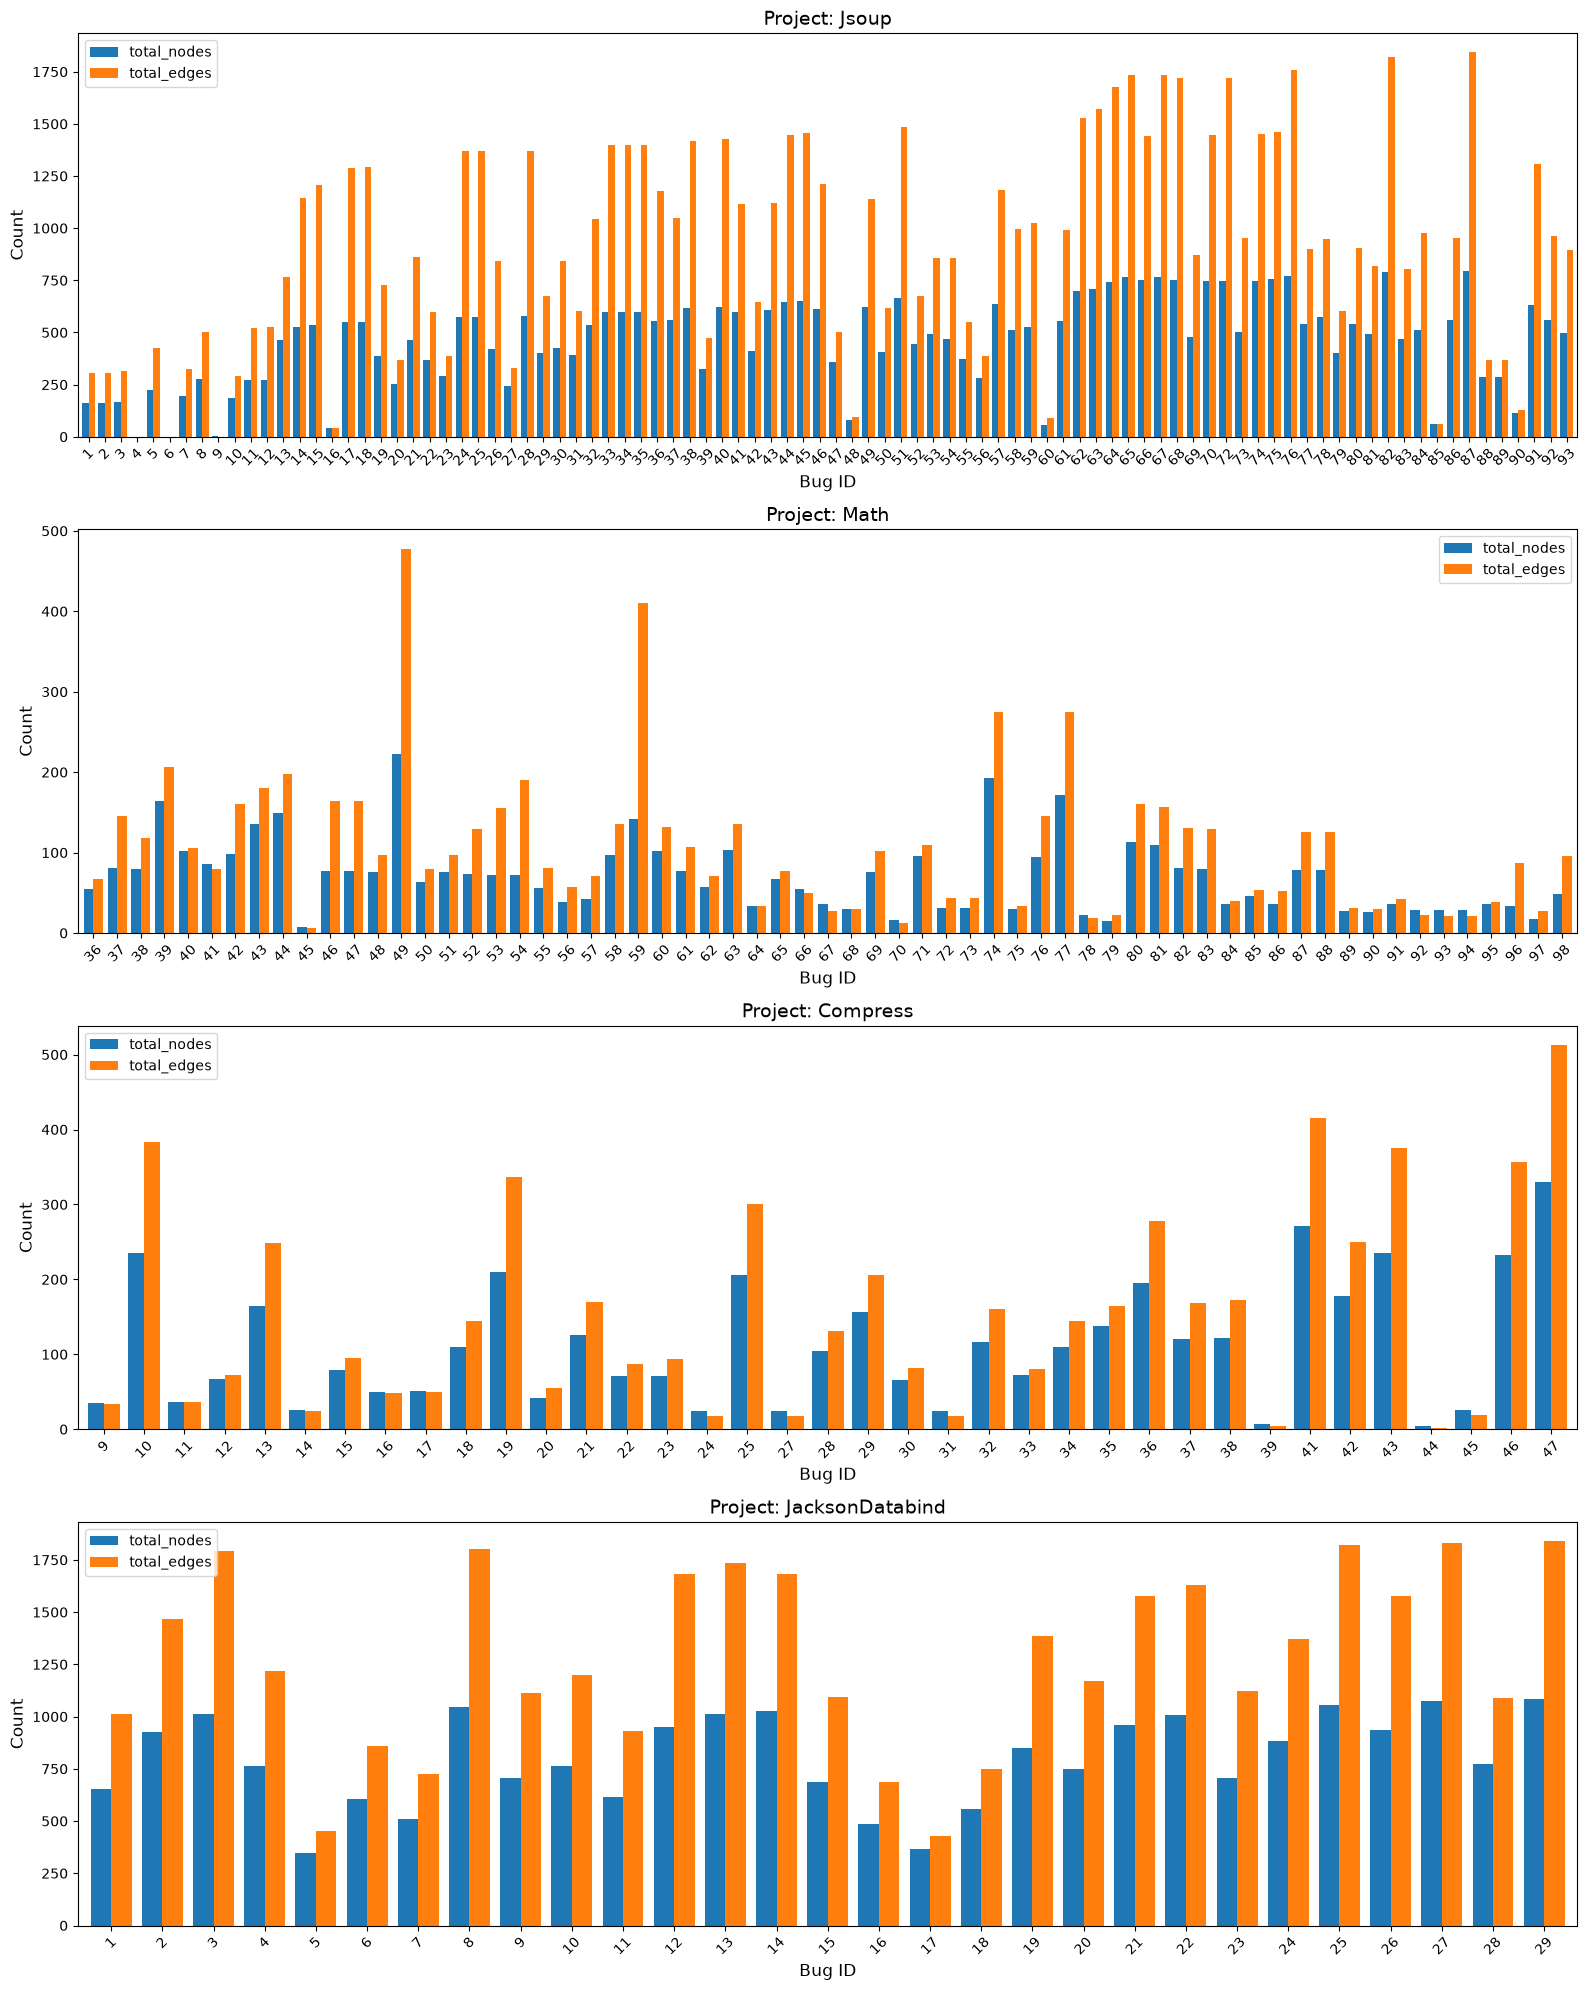

In [12]:
import matplotlib.pyplot as plt

# Get the top 4 projects
top_4_projects = df_active['project'].value_counts().head(4).index

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(16, 20))

for i, project_name in enumerate(top_4_projects):
    # Filter data and sort by bug_id so the X-axis is in numerical order
    project_data = df_active[df_active['project'] == project_name].sort_values('bug_id')
    
    # We temporarily set 'bug_id' as the index so pandas uses it for the X-axis labels
    project_data_indexed = project_data.set_index('bug_id')
    
    # Plot the bar chart
    project_data_indexed[['total_nodes', 'total_edges']].plot(
        kind='bar', 
        ax=axes[i], 
        width=0.8,
        color=['#1f77b4', '#ff7f0e']
    )
    
    axes[i].set_title(f'Project: {project_name}', fontsize=14)
    axes[i].set_xlabel('Bug ID', fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    
    # Make sure we don't crowd the x-axis labels
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [13]:
extraction_res.sbfl_metrics

[{'Method': 'org.jfree.chart.BufferedImageRenderingSource#BufferedImageRenderingSource(java.awt.image.BufferedImage)',
  'Ochiai': 0.0,
  'Tarantula': 0.0,
  'Fail_Executed': 0},
 {'Method': 'org.jfree.chart.BufferedImageRenderingSource#createGraphics2D()',
  'Ochiai': 0.0,
  'Tarantula': 0.0,
  'Fail_Executed': 0},
 {'Method': 'org.jfree.chart.BufferedImageRenderingSource#getSelectionState(org.jfree.data.general.Dataset)',
  'Ochiai': 0.0,
  'Tarantula': 0.0,
  'Fail_Executed': 0},
 {'Method': 'org.jfree.chart.BufferedImageRenderingSource#putSelectionState(org.jfree.data.general.Dataset,org.jfree.data.general.DatasetSelectionState)',
  'Ochiai': 0.0,
  'Tarantula': 0.0,
  'Fail_Executed': 0},
 {'Method': 'org.jfree.chart.ChartColor#ChartColor(int,int,int)',
  'Ochiai': 0.0,
  'Tarantula': 0.0,
  'Fail_Executed': 0},
 {'Method': 'org.jfree.chart.ChartColor#createDefaultPaintArray()',
  'Ochiai': 0.0576390417704235,
  'Tarantula': 0.8797113071371291,
  'Fail_Executed': 1},
 {'Method': '

In [14]:
def plot_project_distribution(project_name, df):
    df_proj = df[df['project'] == project_name]
    plt.figure(figsize=(10, 6))

    plt.hist(df_proj['total_nodes'], bins=20, alpha=0.5, label='Total Nodes', edgecolor='black')
    plt.hist(df_proj['total_edges'], bins=20, alpha=0.5, label='Total Edges', edgecolor='black')
    
    plt.title(f'{project_name}')
    plt.xlabel('Count (Nodes/Edges)', fontsize=12)
    plt.ylabel('Frequency (Number of Instances)', fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


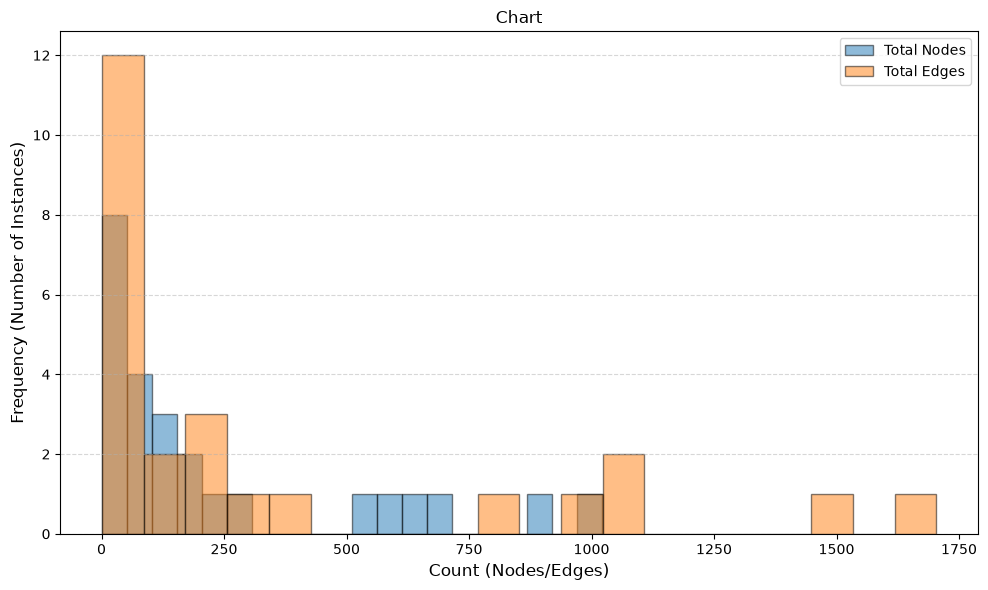

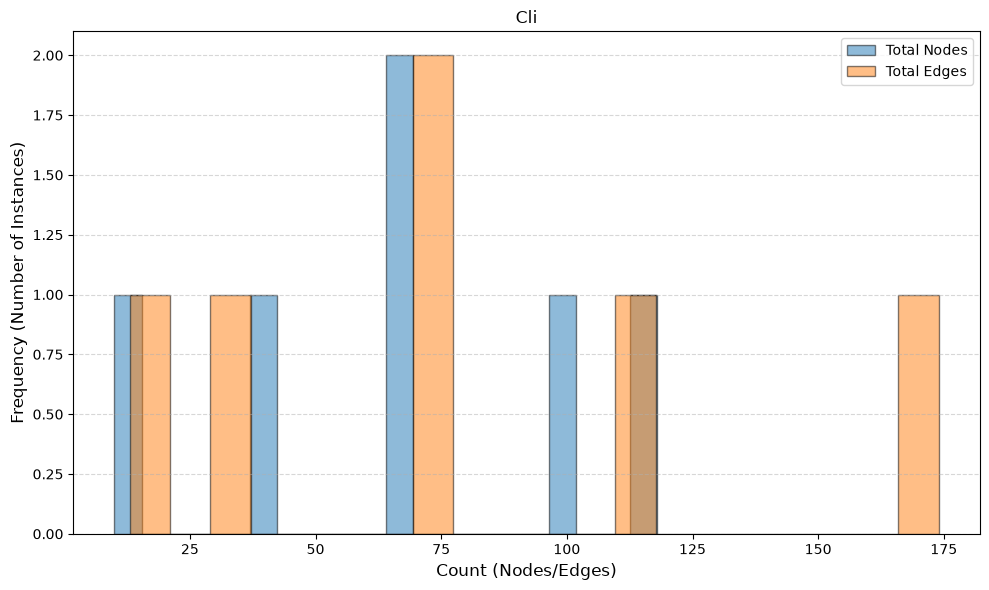

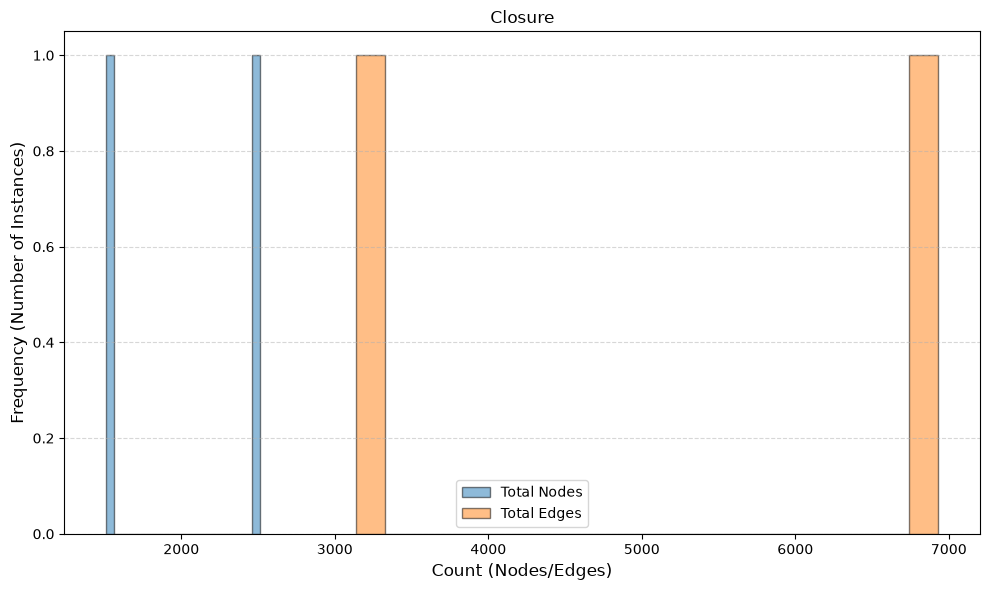

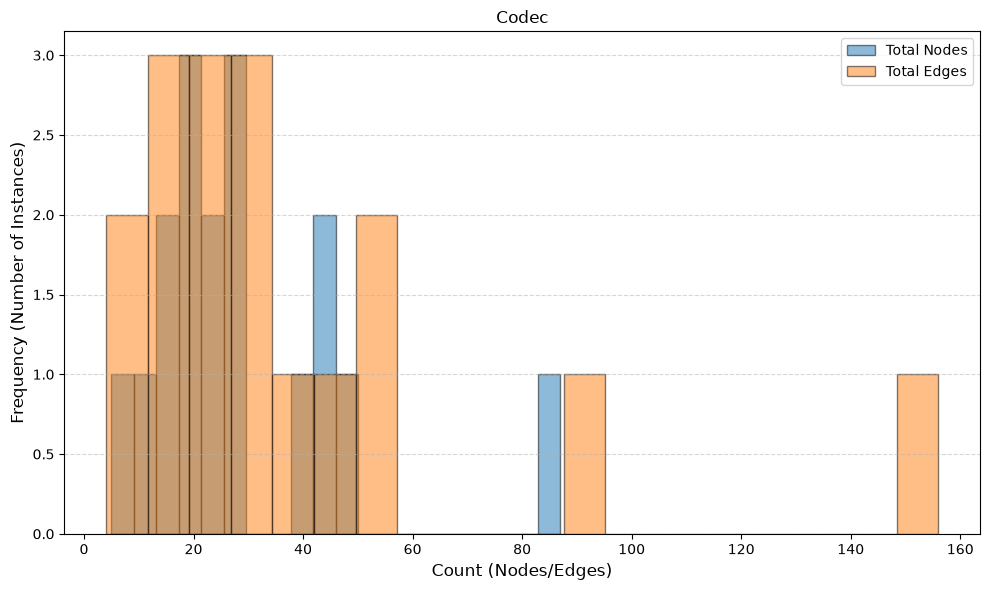

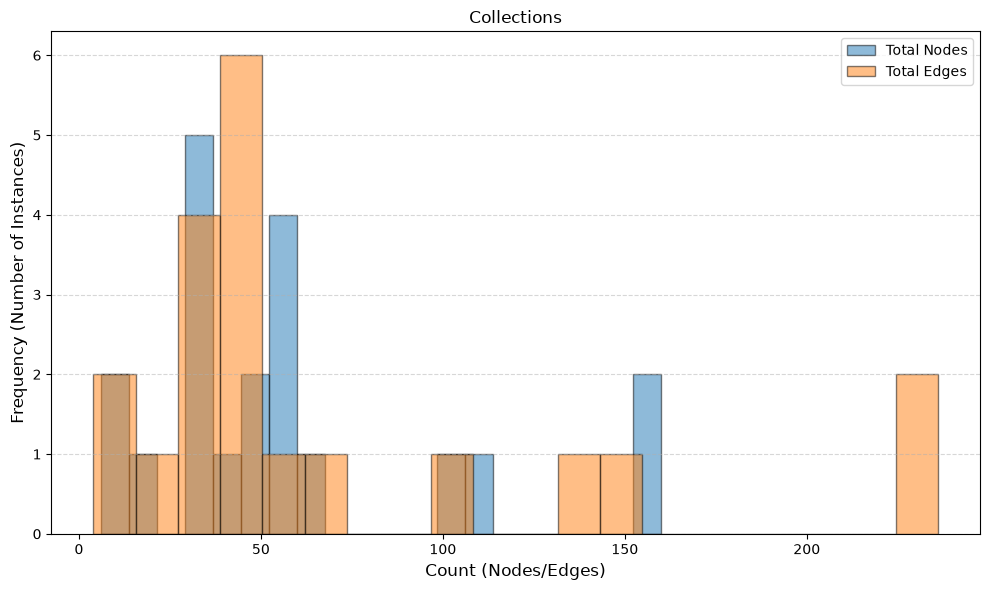

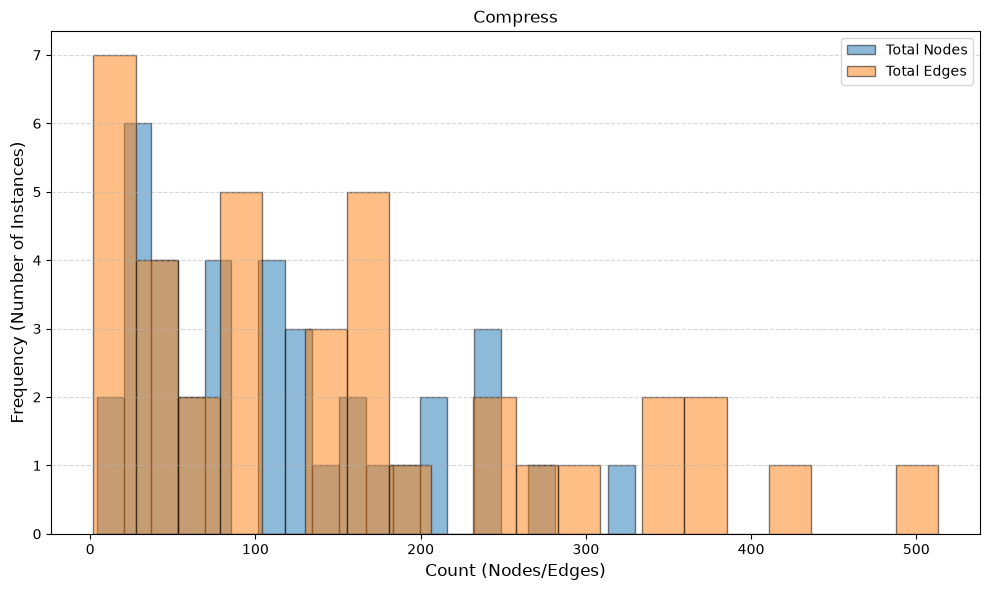

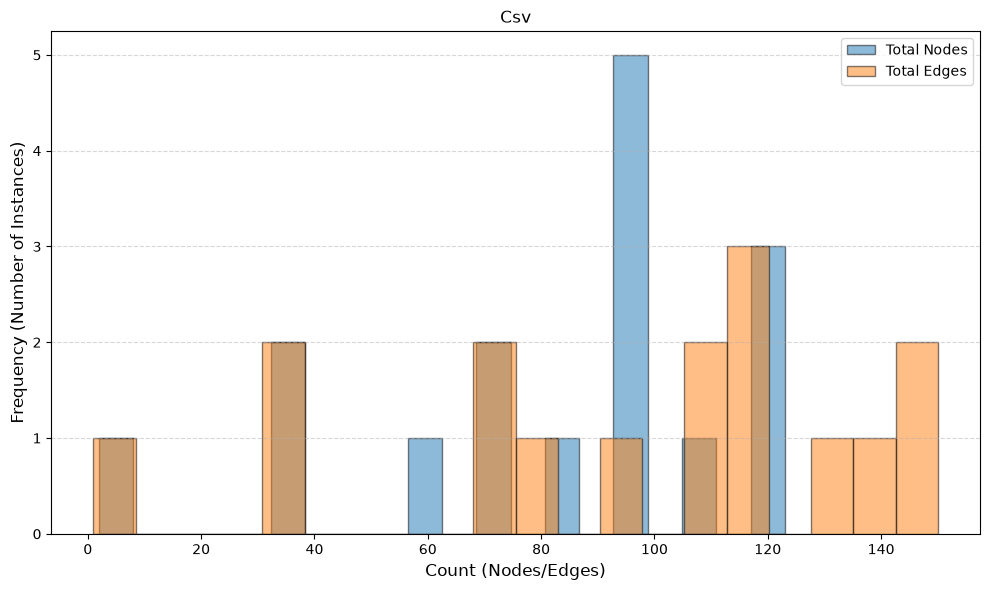

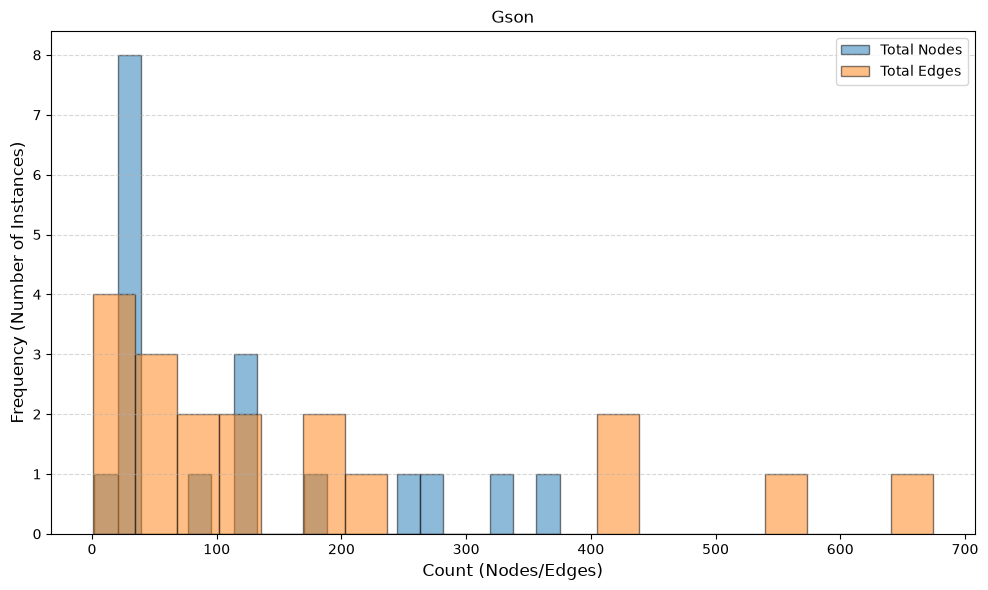

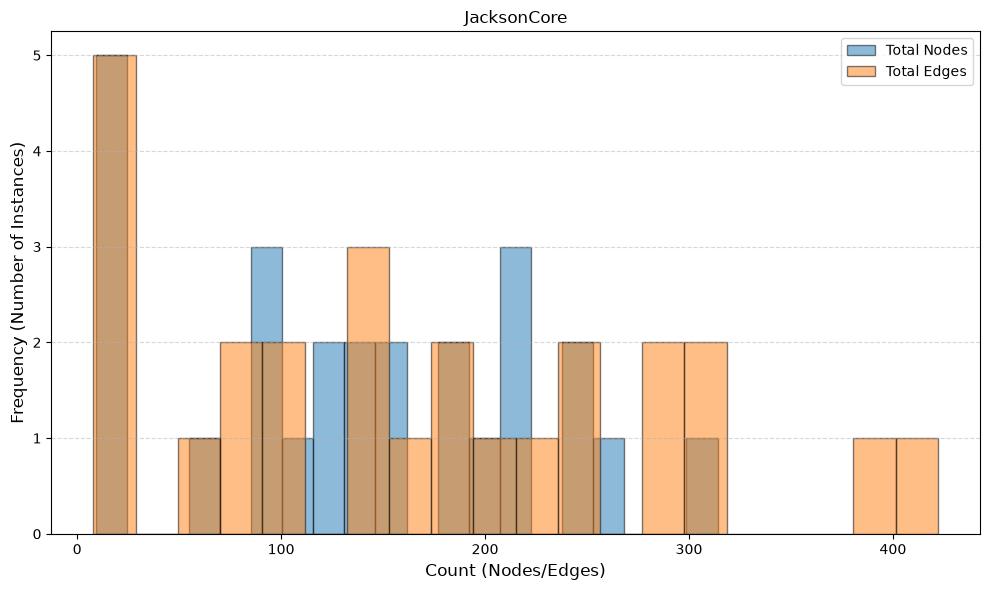

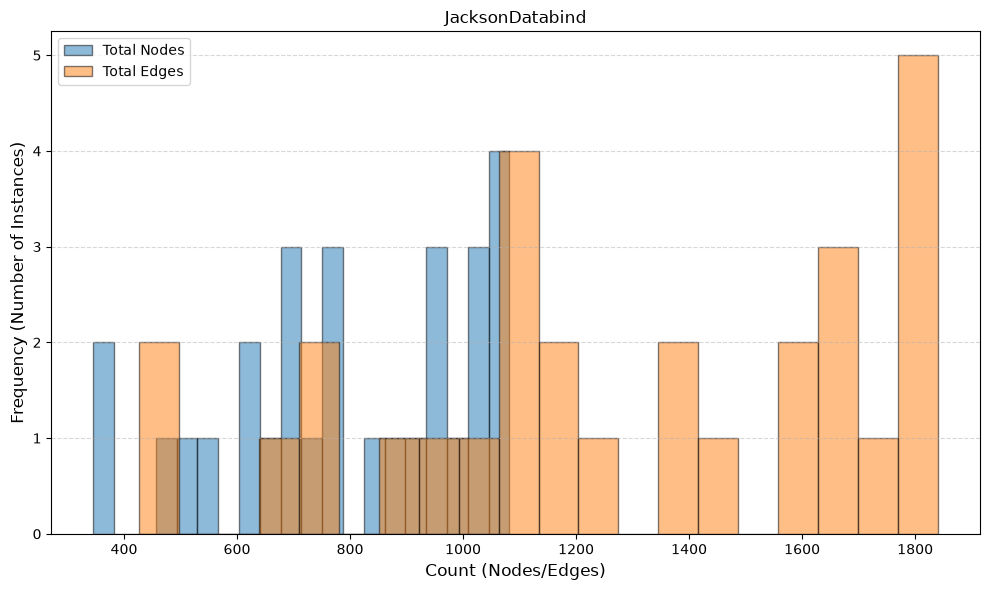

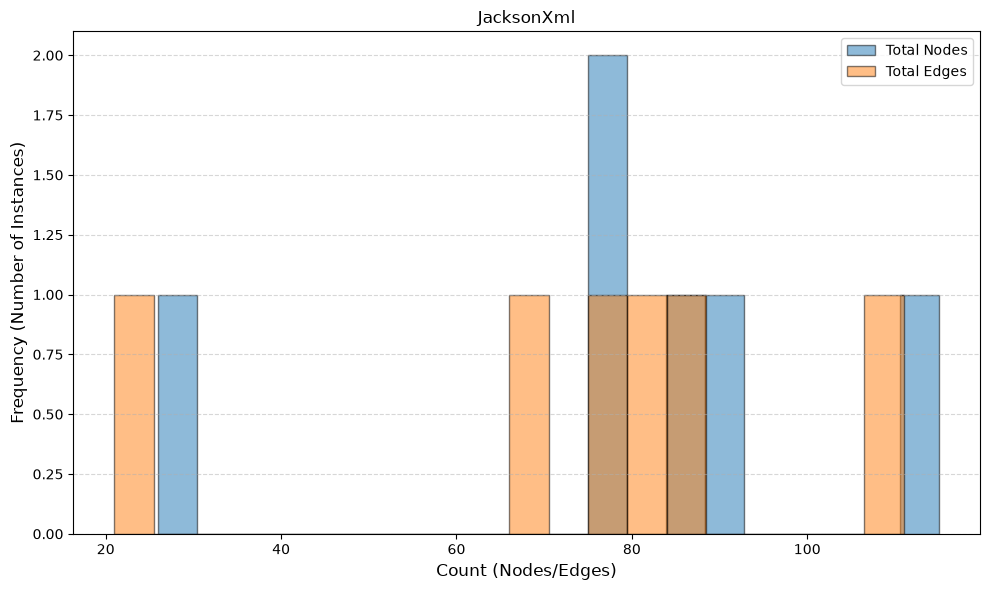

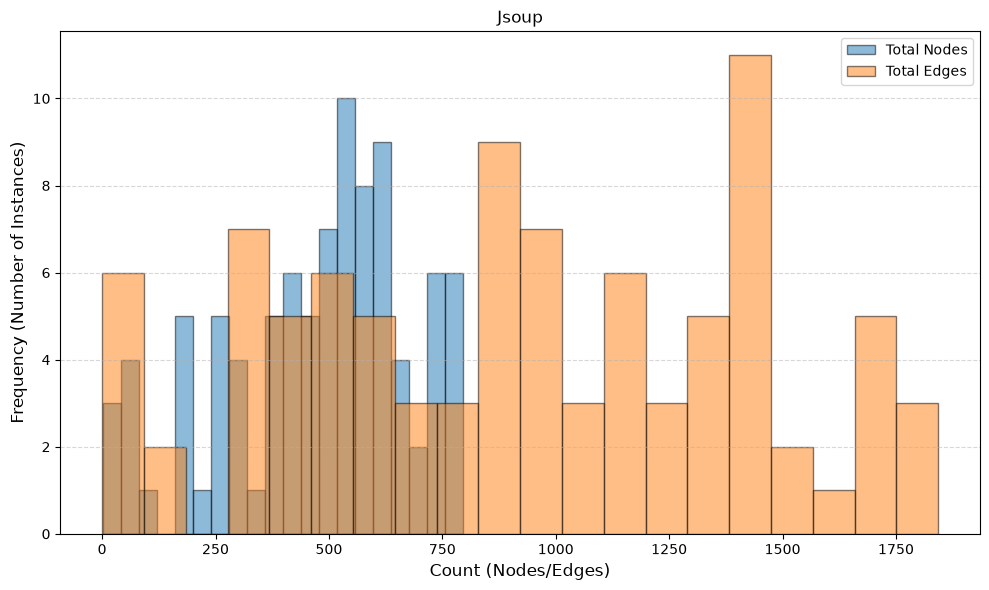

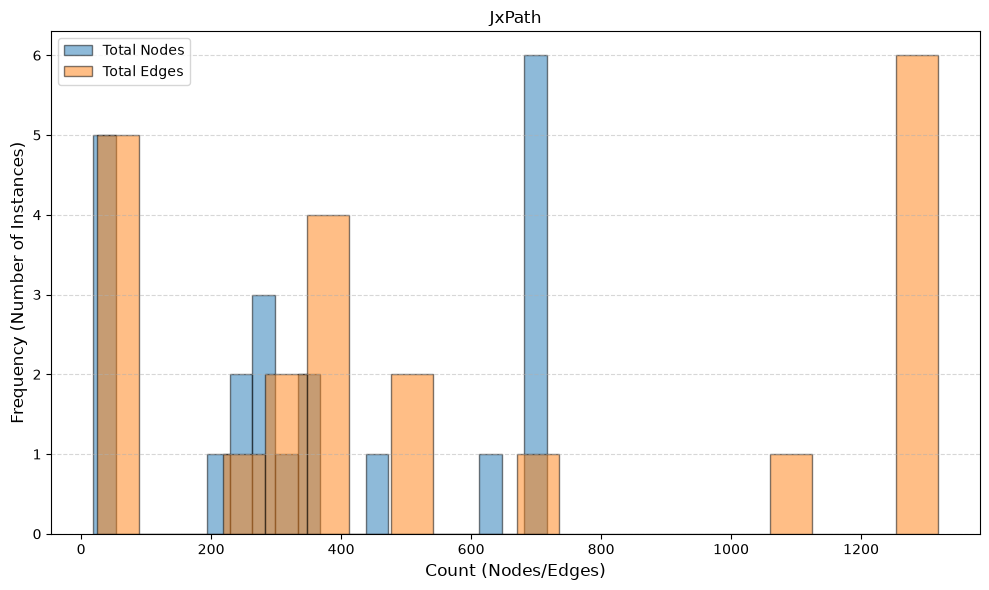

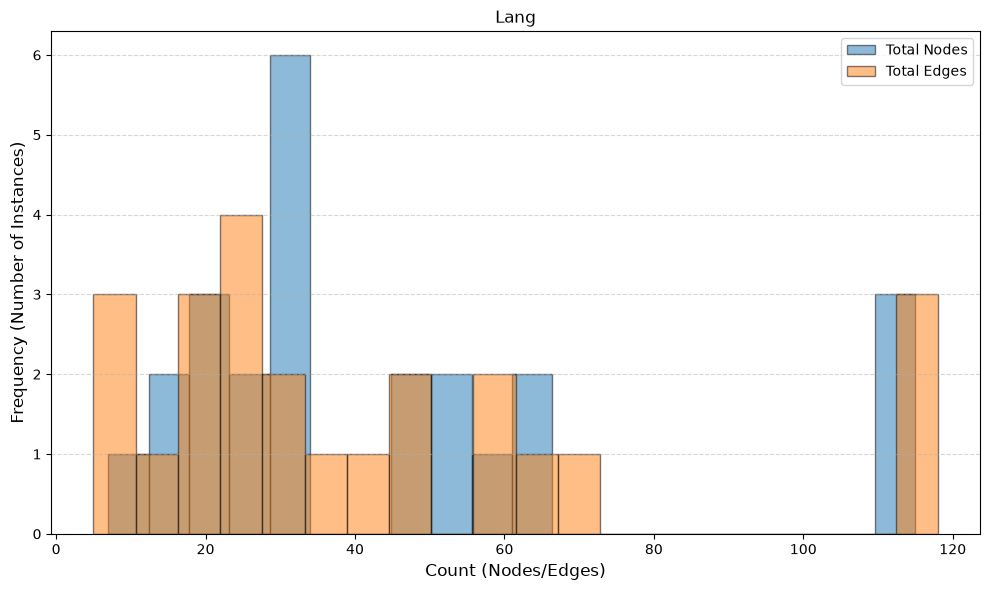

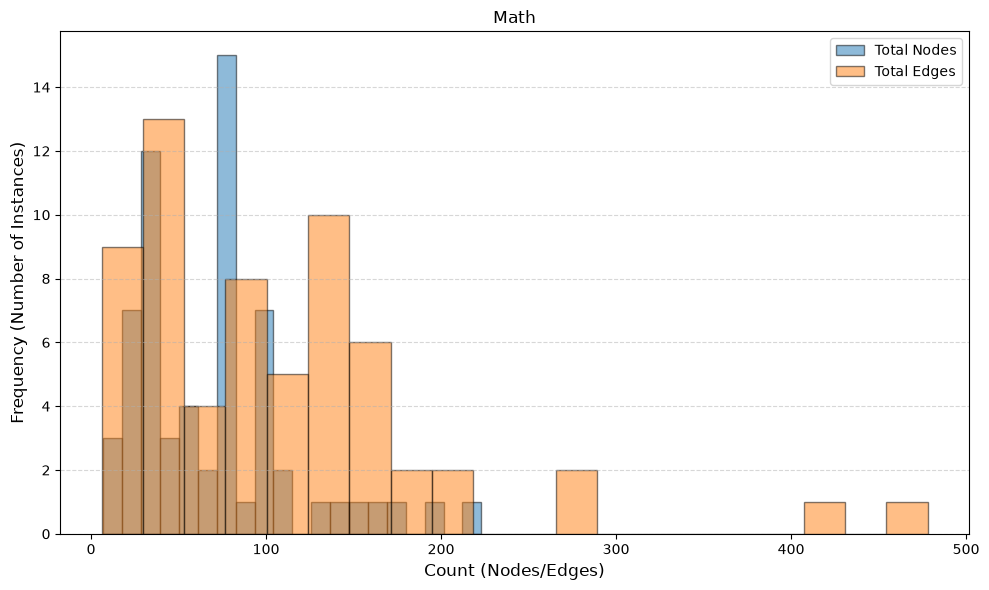

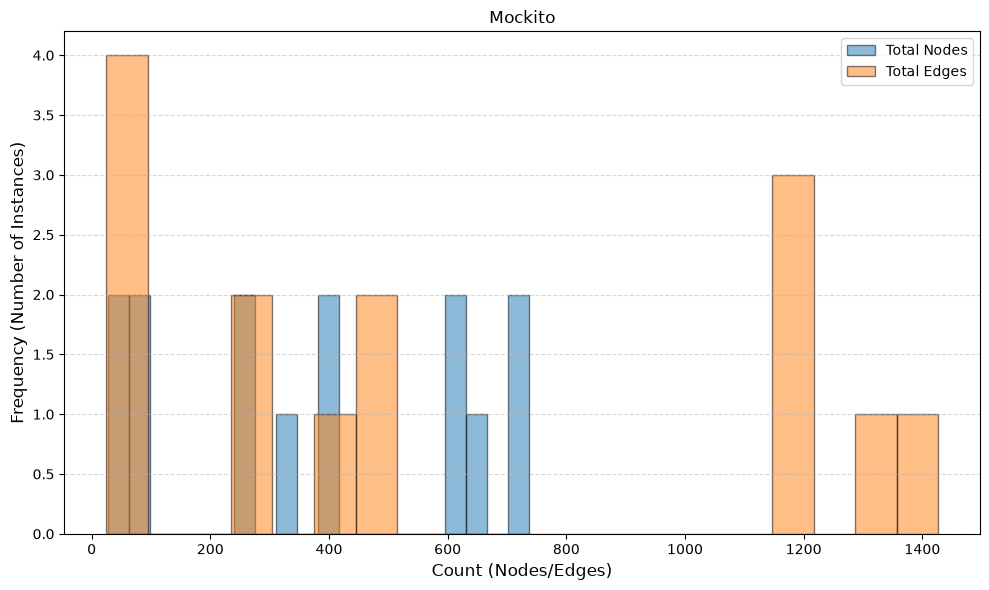

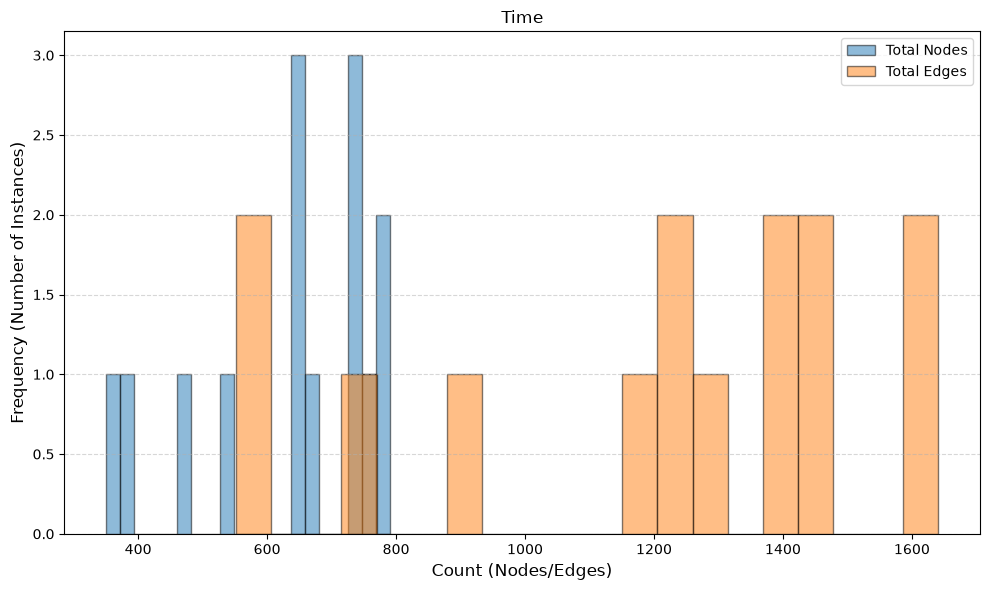

In [15]:
for project in df_active.project.unique():
    plot_project_distribution(project, df_active)

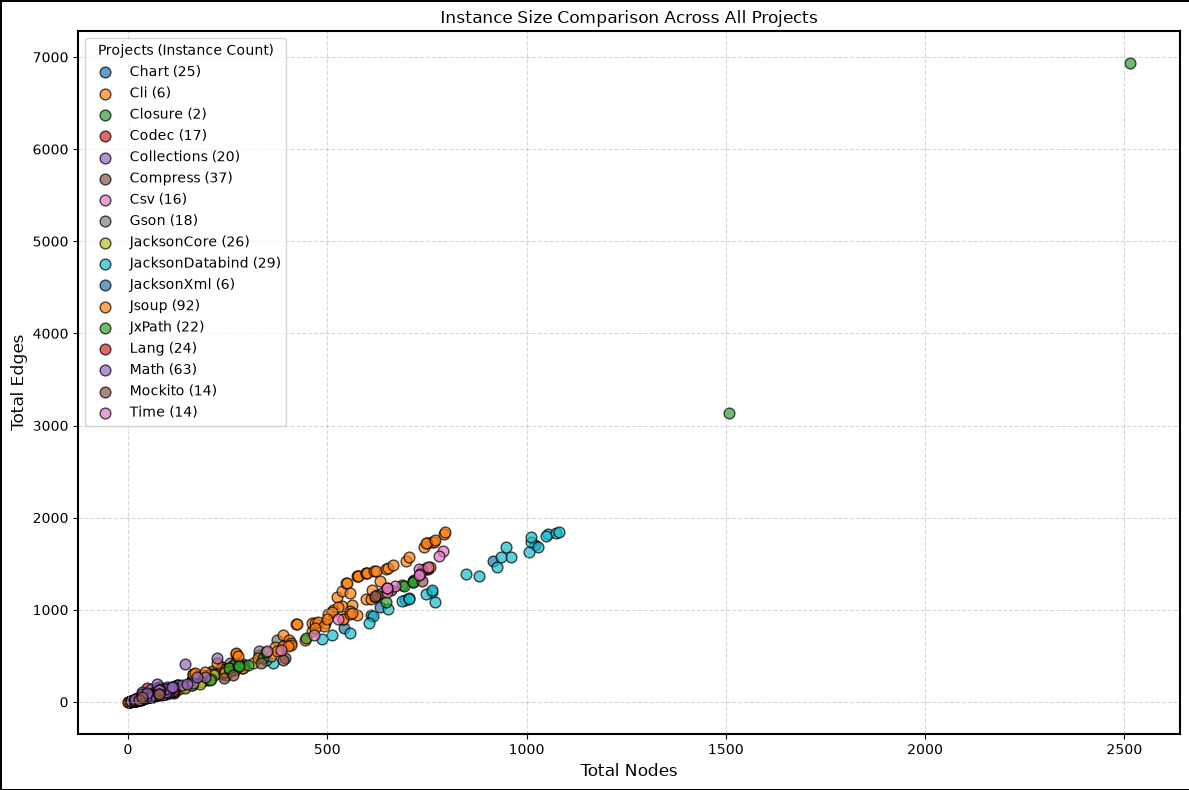

In [16]:
def plot_project_comparison_scatter(df):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for project_name, group_data in df.groupby('project'):
        ax.scatter(
            group_data['total_nodes'], 
            group_data['total_edges'], 
            alpha=0.7, 
            label=f"{project_name} ({len(group_data)})", 
            edgecolors='black', # Crisp borders on the dots
            linewidth=1,
            s=60 # Slightly larger dots for visibility
        )
    
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(2) 
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    plt.title('Instance Size Comparison Across All Projects')
    plt.xlabel('Total Nodes', fontsize=12)
    plt.ylabel('Total Edges', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.legend(title='Projects (Instance Count)', loc='upper left')
    
    plt.tight_layout()
    plt.show()

plot_project_comparison_scatter(df_active)

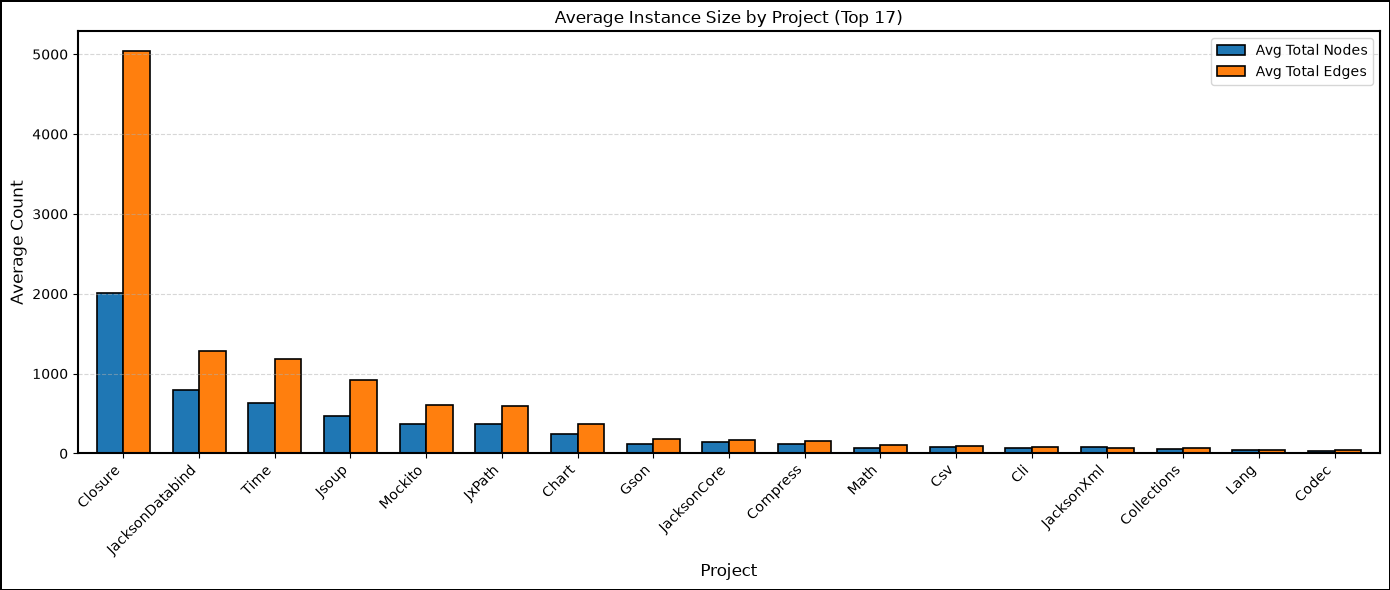

In [17]:
def plot_project_comparison_averages(df):
    df_grouped = df.groupby('project')[['total_nodes', 'total_edges']].mean()
    df_grouped = df_grouped.sort_values('total_edges', ascending=False)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    df_grouped.plot(
        kind='bar', 
        ax=ax,
        width=0.7, 
        color=['#1f77b4', '#ff7f0e'],
        edgecolor='black', # Crisp bar borders
        linewidth=1.2
    )
    
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(2) 
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
        
    plt.title(f'Average Instance Size by Project (Top {len(df_grouped)})')
    plt.xlabel('Project', fontsize=12)
    plt.ylabel('Average Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(['Avg Total Nodes', 'Avg Total Edges'])
    
    plt.tight_layout()
    plt.show()
plot_project_comparison_averages(df_active)

In [18]:
df_active['num_buggy_nodes'].value_counts()

num_buggy_nodes
1     297
2      66
3      26
4      12
0      11
7       5
6       5
5       3
10      2
15      1
8       1
19      1
13      1
Name: count, dtype: int64

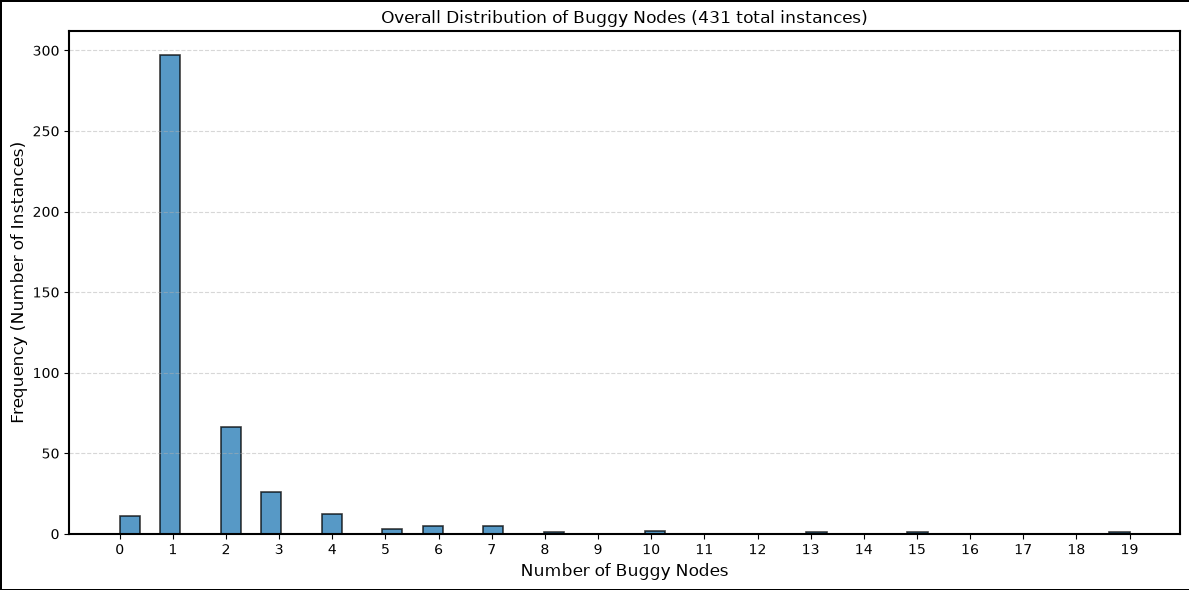

In [19]:
import matplotlib.pyplot as plt

def plot_overall_buggy_nodes_histogram(df, num_bins=40):
    # 1. Extract the data and drop any missing values
    data = df['num_buggy_nodes'].dropna()
    
    # 2. Create the plot setup
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 3. Plot the histogram
    ax.hist(
        data, 
        bins=num_bins, 
        edgecolor='black', 
        linewidth=1.2, 
        alpha=0.75
    )
    
    # 4. Add the thick outer frame border
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(2) 
    
    # 5. Make the inner plot box slightly thicker to match
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
    
    # 6. Standard Formatting
    plt.title(f'Overall Distribution of Buggy Nodes ({len(data)} total instances)')
    plt.xlabel('Number of Buggy Nodes', fontsize=12)
    plt.ylabel('Frequency (Number of Instances)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    min_x = int(data.min())
    max_x = int(data.max())
    plt.xticks(range(min_x, max_x + 1))
    
    plt.tight_layout()
    plt.show()


plot_overall_buggy_nodes_histogram(df_active, num_bins=50)

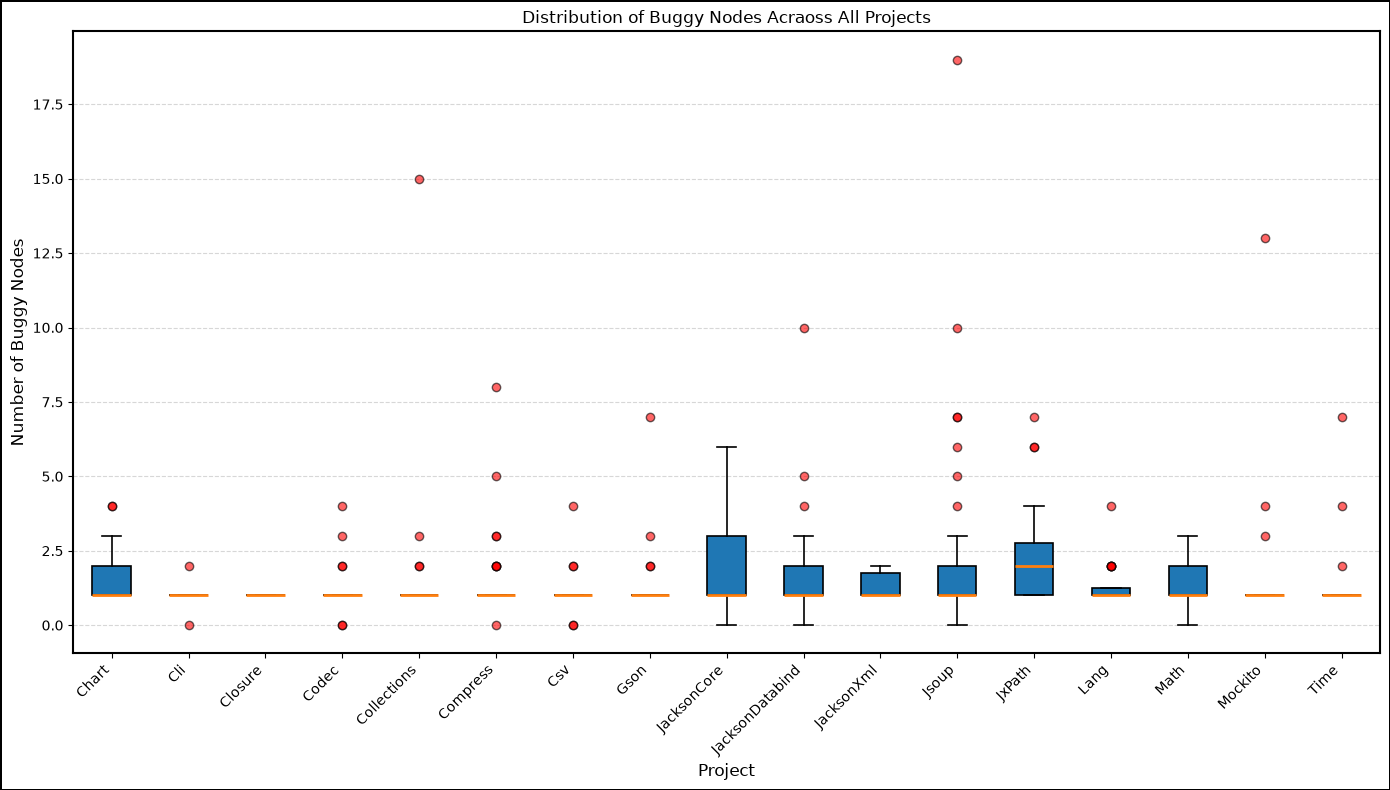

In [20]:
def plot_buggy_nodes_distribution(df):
    fig, ax = plt.subplots(figsize=(14, 8))
    
    projects = sorted(df['project'].unique())
    
    data_to_plot = [df[df['project'] == p]['num_buggy_nodes'].dropna() for p in projects]
    ax.boxplot(
        data_to_plot, 
        tick_labels=projects,
        patch_artist=True, 
        boxprops=dict(facecolor='#1f77b4', color='black', linewidth=1.2), 
        medianprops=dict(color='#ff7f0e', linewidth=2),                   
        whiskerprops=dict(color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2),
        flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.6) 
    )
    
    # Outer frame and inner spines
    fig.patch.set_edgecolor('black')
    fig.patch.set_linewidth(2) 
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)
        
    # Formatting
    plt.title('Distribution of Buggy Nodes Acraoss All Projects')
    plt.xlabel('Project', fontsize=12)
    plt.ylabel('Number of Buggy Nodes', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_buggy_nodes_distribution(df_active)

# Subset selection

Use only single bug instances

In [21]:
single_bug_instances = df_active[df_active['num_buggy_nodes']==1]
single_bug_instances

,total_nodes,total_edges,buggy_nodes,num_buggy_nodes,project,bug_id
Chart_1,198,239,[org.jfree.chart.renderer.category.AbstractCat...,1,Chart,1
Chart_11,7,6,[org.jfree.chart.util.ShapeUtilities#equal],1,Chart,11
Chart_12,184,239,[org.jfree.chart.plot.MultiplePiePlot#Multiple...,1,Chart,12
Chart_13,64,83,[org.jfree.chart.block.BorderArrangement#Range],1,Chart,13
Chart_17,110,157,[org.jfree.data.time.TimeSeries#delete],1,Chart,17
...,...,...,...,...,...,...
Time_22,650,1191,[org.joda.time.base.BasePeriod#BasePeriod],1,Time,22
Time_23,468,724,[org.joda.time.DateTimeZone#getConvertedId],1,Time,23
Time_24,780,1588,[org.joda.time.format.DateTimeParserBucket#com...,1,Time,24
Time_25,651,1234,[org.joda.time.DateTimeZone#getOffsetFromLocal],1,Time,25


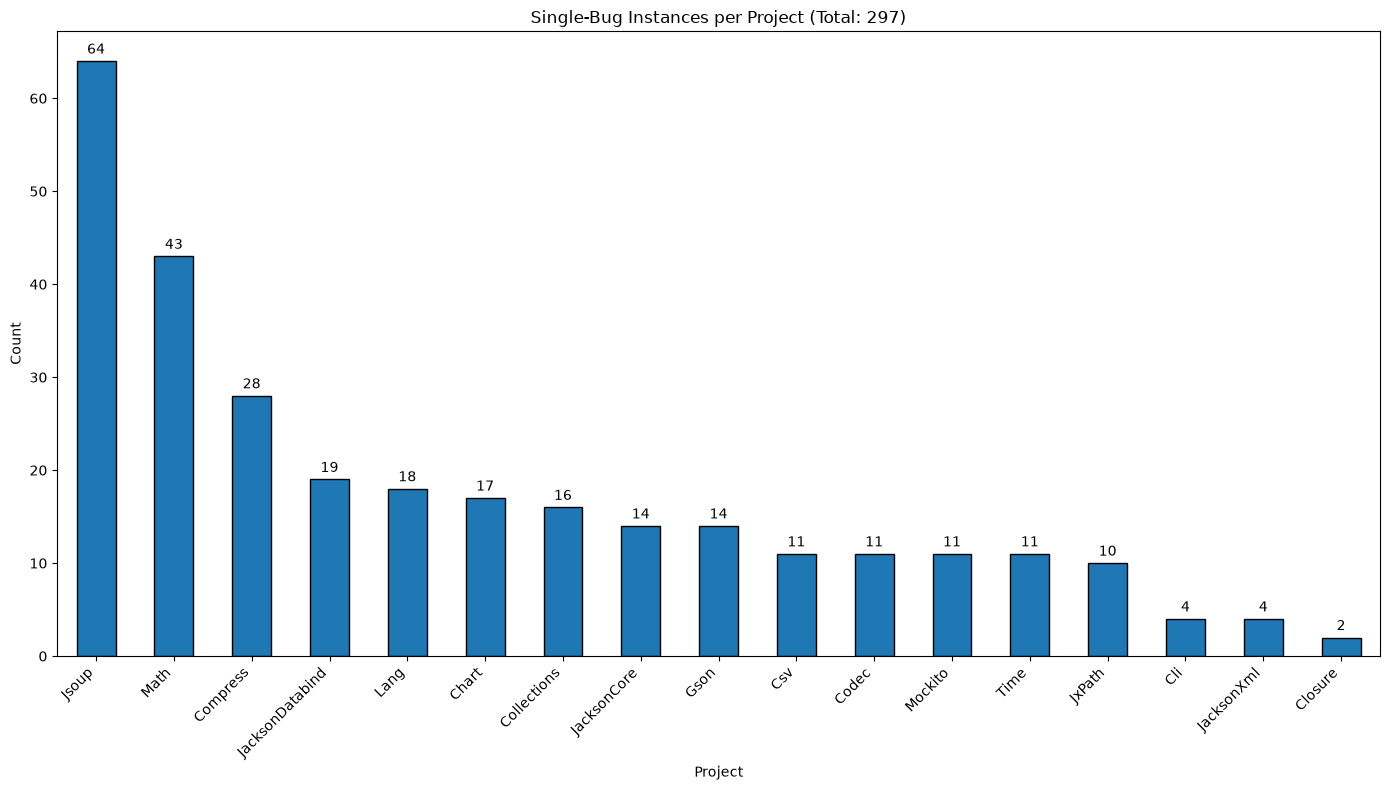

In [22]:
import matplotlib.pyplot as plt

single_bug_counts = single_bug_instances['project'].value_counts()
plt.figure(figsize=(14, 8))

# Save the plot to an 'ax' variable so we can add labels to it
ax = single_bug_counts.plot(kind='bar', edgecolor='black')

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

# Add basic labels
plt.title(f'Single-Bug Instances per Project (Total: {len(single_bug_instances)})')
plt.xlabel('Project')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

# Baselines

In [23]:
def compute_method_tarantula(coverage_csv: str) -> dict[str, float]:
    df = pd.read_csv(coverage_csv)
    
    # Aggregate line level to method level
    method_data = {}
    for col in df.columns:
        if col == 'Result':
            continue
        method = map_line_to_method(col)
        if method not in method_data:
            method_data[method] = df[col].copy()
        else:
            method_data[method] = method_data[method] | df[col]
            
    method_df = pd.DataFrame(method_data)
    method_df['Result'] = df['Result']
    
    total_fail = len(method_df[method_df['Result'] == 'Fail'])
    total_pass = len(method_df[method_df['Result'] == 'Pass'])
    
    tarantula_scores = {}
    for method in method_df.columns:
        if method == 'Result':
            continue
        cf = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Fail')])
        cp = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Pass')])
        
        if total_fail == 0 or (cf == 0 and cp == 0):
            tarantula = 0.0
        else:
            fail_ratio = cf / total_fail
            pass_ratio = cp / total_pass if total_pass > 0 else 0.0
            if fail_ratio + pass_ratio == 0:
                tarantula = 0.0
            else:
                tarantula = fail_ratio / (fail_ratio + pass_ratio)
                
        tarantula_scores[method] = float(tarantula)
        
    return tarantula_scores

def map_line_to_method(line_name: str) -> str:
    """Maps a coverage column like 'com.example$App#process(int):30' to 'com.example.App#process(int)'."""
    if "#" not in line_name:
        return line_name.replace('$', '.')
    return line_name.split(':')[0].replace('$', '.')

def compute_method_ochiai(coverage_csv: str) -> dict[str, float]:
    """
    Computes Ochiai suspiciousness score for each method based on the coverage matrix.
    Aggregates lines into methods using OR logic before computing the score.
    """
    df = pd.read_csv(coverage_csv)
    
    # 1. Aggregate line level to method level (Same as your Tarantula code)
    method_data = {}
    for col in df.columns:
        if col == 'Result':
            continue
        method = map_line_to_method(col)
        if method not in method_data:
            method_data[method] = df[col].copy()
        else:
            method_data[method] = method_data[method] | df[col]
            
    method_df = pd.DataFrame(method_data)
    method_df['Result'] = df['Result']
    
    # 2. Global metric: Ochiai only needs total_fail, not total_pass
    total_fail = len(method_df[method_df['Result'] == 'Fail'])
    
    ochiai_scores = {}
    for method in method_df.columns:
        if method == 'Result':
            continue
            
        # 3. Local metrics
        cf = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Fail')])
        cp = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Pass')])
        
        # 4. Ochiai Math & Edge Case Handling
        # Prevent division by zero if there are no fails or the method is never covered
        if total_fail == 0 or (cf + cp) == 0:
            ochiai = 0.0
        else:
            # The Ochiai Equation
            ochiai = cf / math.sqrt(total_fail * (cf + cp))
                
        ochiai_scores[method] = float(ochiai)
        
    return ochiai_scores


def compute_method_dstar(coverage_csv: str, star: int = 2) -> dict[str, float]:
    """
    Computes D* (D-Star) suspiciousness score for each method based on the coverage matrix.
    Aggregates lines into methods using OR logic before computing the score.
    The 'star' parameter controls the exponent weight (default is 2).
    """
    df = pd.read_csv(coverage_csv)
    
    # 1. Aggregate line level to method level
    method_data = {}
    for col in df.columns:
        if col == 'Result':
            continue
        method = map_line_to_method(col)
        if method not in method_data:
            method_data[method] = df[col].copy()
        else:
            method_data[method] = method_data[method] | df[col]
            
    method_df = pd.DataFrame(method_data)
    method_df['Result'] = df['Result']
    
    # 2. Global metric: D* needs total_fail
    total_fail = len(method_df[method_df['Result'] == 'Fail'])
    
    dstar_scores = {}
    for method in method_df.columns:
        if method == 'Result':
            continue
            
        # 3. Local metrics
        cf = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Fail')])
        cp = len(method_df[(method_df[method] == 1) & (method_df['Result'] == 'Pass')])
        
        # nf is the number of failing tests that DID NOT execute this method
        nf = total_fail - cf
        denominator = cp + nf
        
        # 4. D* Math & Edge Case Handling
        if denominator == 0:
            if cf > 0:
                dstar = float('inf')
            else:
                dstar = 0.0
        else:
            dstar = (cf ** star) / denominator
                
        dstar_scores[method] = float(dstar)
        
    return dstar_scores

In [24]:
instance

PosixPath('/Users/ashish/master-thesis/Master-Thesis/failure-propagation-and-rca-via-energy-minimization/data/defects4j/Chart_1')

In [25]:
coverage_csv = instance / "coverage.csv"
coverage_df = pd.read_csv(coverage_csv)
coverage_df

,org.jfree.chart.imagemap$StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator():52,org.jfree.chart.imagemap$StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator():53,org.jfree.chart.imagemap$StandardURLTagFragmentGenerator#generateURLFragment(java.lang.String):64,org.jfree.chart.imagemap$ImageMapUtilities#ImageMapUtilities():66,"org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo):81","org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo):85","org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean):102","org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean):103","org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean):104","org.jfree.chart.imagemap$ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean):108",...,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(org.jfree.data.xy.MatrixSeries):317,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(org.jfree.data.xy.MatrixSeries):320,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):334,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):335,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):339,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):340,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):341,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):342,org.jfree.data.xy$MatrixSeriesCollection#removeSeries(int):344,Result
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2190,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2191,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2192,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass
2193,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pass


In [26]:
tarantula = compute_method_tarantula(coverage_csv)
tarantula

{'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator()': 0.0,
 'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#generateURLFragment(java.lang.String)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#ImageMapUtilities()': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,org.jfree.chart.imagemap.ToolTipTagFragmentGenerator,org.jfree.chart.imagemap.URLTagFragmentGenerator)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jf

In [27]:
ochiai = compute_method_ochiai(coverage_csv)
ochiai

{'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator()': 0.0,
 'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#generateURLFragment(java.lang.String)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#ImageMapUtilities()': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,org.jfree.chart.imagemap.ToolTipTagFragmentGenerator,org.jfree.chart.imagemap.URLTagFragmentGenerator)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jf

In [28]:
dstar = compute_method_dstar(coverage_csv)
dstar

{'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator()': 0.0,
 'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#generateURLFragment(java.lang.String)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#ImageMapUtilities()': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,org.jfree.chart.imagemap.ToolTipTagFragmentGenerator,org.jfree.chart.imagemap.URLTagFragmentGenerator)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jfree.chart.ChartRenderingInfo)': 0.0,
 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jf

In [29]:
nodes = G.nodes()
nodes_t = tarantula.keys()

x = [node for node in nodes_t if node in nodes]

In [30]:
len(nodes), len(x)

(198, 198)

In [31]:
nodes = G.nodes()
nodes_o = ochiai.keys()

y = [node for node in nodes_o if node in nodes]

In [32]:
len(nodes), len(y)

(198, 198)

In [33]:
nodes = G.nodes()
nodes_d = dstar.keys()

z = [node for node in nodes_d if node in nodes]

In [34]:
len(nodes), len(z)

(198, 198)

In [35]:
sbfl_metrics = pd.DataFrame({
    "tarantula": {node: tarantula[node] for node in x if node in tarantula},
    "ochiai": {node: ochiai[node] for node in y if node in ochiai},
    "dstar": {node: dstar[node] for node in z if node in dstar},
})
sbfl_metrics

,tarantula,ochiai,dstar
org.jfree.chart.renderer.AbstractRenderer#AbstractRenderer(),0.818351,0.045268,0.002053
org.jfree.chart.renderer.AbstractRenderer#isSeriesVisible(int),0.000000,0.000000,0.000000
org.jfree.chart.renderer.AbstractRenderer#setBaseLegendShape(java.awt.Shape),0.000000,0.000000,0.000000
org.jfree.chart.renderer.AbstractRenderer#getDataBoundsIncludesVisibleSeriesOnly(),0.000000,0.000000,0.000000
org.jfree.chart.renderer.AbstractRenderer#addChangeListener(org.jfree.chart.event.RendererChangeListener),0.917224,0.070888,0.005051
...,...,...,...
org.jfree.chart.annotations.CategoryTextAnnotation#getCategory(),0.000000,0.000000,0.000000
org.jfree.chart.annotations.CategoryTextAnnotation#getCategoryAnchor(),0.000000,0.000000,0.000000
org.jfree.chart.annotations.CategoryTextAnnotation#getValue(),0.000000,0.000000,0.000000
org.jfree.chart.annotations.CategoryTextAnnotation#equals(java.lang.Object),0.000000,0.000000,0.000000


In [36]:
sbfl_metrics.sort_values(by='tarantula', ascending=False)

,tarantula,ochiai,dstar
org.jfree.chart.plot.CategoryPlot#setRenderer(org.jfree.chart.renderer.category.CategoryItemRenderer),0.998180,0.447214,0.250000
"org.jfree.chart.plot.CategoryPlot#setRenderer(int,org.jfree.chart.renderer.category.CategoryItemRenderer,boolean)",0.996820,0.353553,0.142857
org.jfree.chart.plot.CategoryPlot#CategoryPlot(),0.993659,0.258199,0.071429
org.jfree.chart.plot.CategoryPlot#setDataset(org.jfree.data.category.CategoryDataset),0.993659,0.258199,0.071429
"org.jfree.chart.plot.CategoryPlot#setDataset(int,org.jfree.data.category.CategoryDataset)",0.990072,0.208514,0.045455
...,...,...,...
org.jfree.chart.util.StandardGradientPaintTransformer#StandardGradientPaintTransformer(org.jfree.chart.util.GradientPaintTransformType),0.000000,0.000000,0.000000
org.jfree.chart.util.StandardGradientPaintTransformer#equals(java.lang.Object),0.000000,0.000000,0.000000
org.jfree.chart.util.GradientPaintTransformType#GradientPaintTransformType(java.lang.String),0.000000,0.000000,0.000000
org.jfree.chart.event.RendererChangeEvent#RendererChangeEvent(java.lang.Object),0.000000,0.000000,0.000000


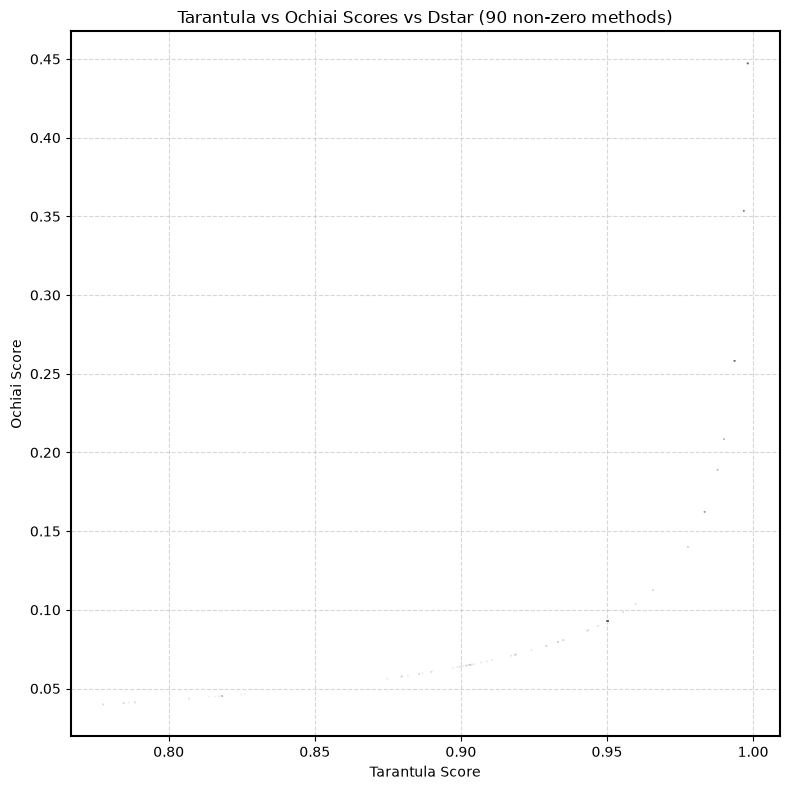

In [37]:
import matplotlib.pyplot as plt

# 1. Filter out methods where BOTH scores are exactly 0
# This keeps rows where either Tarantula > 0 OR Ochiai > 0
filtered_metrics = sbfl_metrics[(sbfl_metrics['tarantula'] > 0) | (sbfl_metrics['ochiai'] > 0) | (sbfl_metrics['dstar'] > 0)]

# 2. Create the plot setup
plt.figure(figsize=(8, 8))
ax = plt.gca()

# 3. Plot the scatter comparison
plt.scatter(
    filtered_metrics['tarantula'], 
    filtered_metrics['ochiai'], 
    filtered_metrics['dstar'], 
    alpha=0.7, 
    edgecolor='black' # Crisp border on the dots
)

# 4. Add the thick black border around the plot
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# 5. Standard Defaults
plt.title(f'Tarantula vs Ochiai Scores vs Dstar ({len(filtered_metrics)} non-zero methods)')
plt.xlabel('Tarantula Score')
plt.ylabel('Ochiai Score')
plt.grid(linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

Spearman Rank Correlation: 1.000


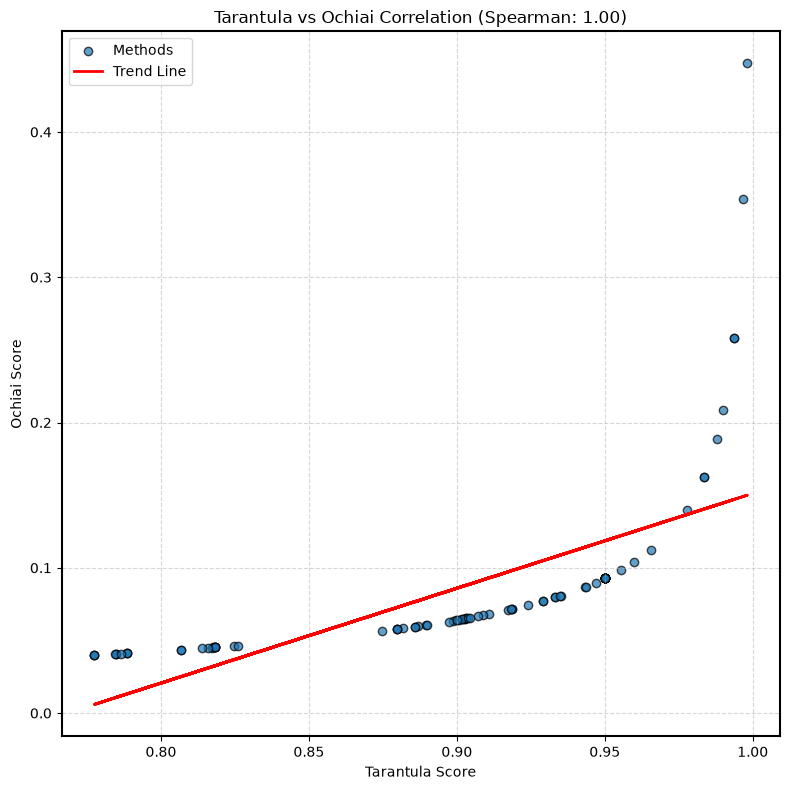

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter out the double-zeros again so they don't artificially inflate the correlation
filtered_metrics = sbfl_metrics[(sbfl_metrics['tarantula'] > 0) | (sbfl_metrics['ochiai'] > 0)]

x = filtered_metrics['tarantula']
y = filtered_metrics['ochiai']

# 2. Calculate the Spearman Rank Correlation using pandas
# 1.0 means perfect agreement in rankings, 0.0 means completely random
correlation = x.corr(y, method='spearman')
print(f"Spearman Rank Correlation: {correlation:.3f}")

# 3. Create the plot setup
plt.figure(figsize=(8, 8))
ax = plt.gca()

# Plot the scatter points
plt.scatter(x, y, alpha=0.7, edgecolor='black', label='Methods')

# 4. Calculate and plot the Line of Best Fit (Trend line)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, linestyle='-', label='Trend Line')

# 5. Add the thick black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# 6. Standard Formatting
plt.title(f'Tarantula vs Ochiai Correlation (Spearman: {correlation:.2f})')
plt.xlabel('Tarantula Score')
plt.ylabel('Ochiai Score')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

Spearman Rank Correlation: 1.000


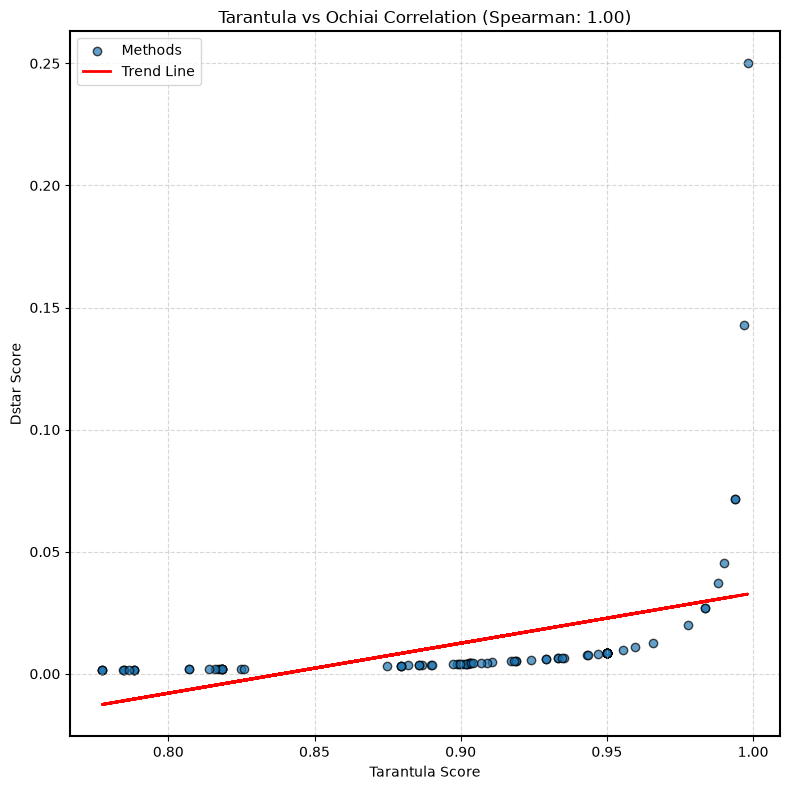

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Filter out the double-zeros again so they don't artificially inflate the correlation
filtered_metrics = sbfl_metrics[(sbfl_metrics['tarantula'] > 0) | (sbfl_metrics['ochiai'] > 0)]

x = filtered_metrics['tarantula']
y = filtered_metrics['dstar']

# 2. Calculate the Spearman Rank Correlation using pandas
# 1.0 means perfect agreement in rankings, 0.0 means completely random
correlation = x.corr(y, method='spearman')
print(f"Spearman Rank Correlation: {correlation:.3f}")

# 3. Create the plot setup
plt.figure(figsize=(8, 8))
ax = plt.gca()

# Plot the scatter points
plt.scatter(x, y, alpha=0.7, edgecolor='black', label='Methods')

# 4. Calculate and plot the Line of Best Fit (Trend line)
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2, linestyle='-', label='Trend Line')

# 5. Add the thick black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# 6. Standard Formatting
plt.title(f'Tarantula vs Ochiai Correlation (Spearman: {correlation:.2f})')
plt.xlabel('Tarantula Score')
plt.ylabel('Dstar Score')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

# Applying Boykov Jolly and min marginals

In [40]:
cut_algo = BoykovJollyCut(G, tarantula, lambd=1)
cut_algo

In [41]:
cut_scores = []
for node in cut_algo.nodes:
    e0, e1 = cut_algo.compute_min_marginals(node)
    confidence = e0 - e1 # Higher is more buggy
    cut_scores.append({"Method": node, "GraphCut_Score": confidence})

In [42]:
cut_df = pd.DataFrame(cut_scores)
cut_df.sort_values(by="GraphCut_Score", ascending=False)

,Method,GraphCut_Score
148,org.jfree.chart.plot.CategoryPlot#setRenderer(...,6.307187e+00
27,org.jfree.chart.plot.CategoryPlot#setRenderer(...,5.747571e+00
65,org.jfree.chart.plot.CategoryPlot#setDataset(o...,5.054424e+00
77,org.jfree.chart.plot.CategoryPlot#CategoryPlot(),5.054424e+00
56,org.jfree.chart.plot.CategoryPlot#setDataset(i...,4.602439e+00
...,...,...
16,org.jfree.chart.util.Layer#equals(java.lang.Ob...,-1.000000e+09
12,org.jfree.chart.util.AbstractObjectList#equals...,-1.000000e+09
13,org.jfree.chart.renderer.category.AbstractCate...,-1.000000e+09
14,org.jfree.chart.event.RendererChangeEvent#Rend...,-1.000000e+09


In [45]:
sbfl_metrics = sbfl_metrics.reset_index().rename(columns={'index': 'Method'})
sbfl_metrics

,Method,tarantula,ochiai,dstar
0,org.jfree.chart.renderer.AbstractRenderer#Abst...,0.818351,0.045268,0.002053
1,org.jfree.chart.renderer.AbstractRenderer#isSe...,0.000000,0.000000,0.000000
2,org.jfree.chart.renderer.AbstractRenderer#setB...,0.000000,0.000000,0.000000
3,org.jfree.chart.renderer.AbstractRenderer#getD...,0.000000,0.000000,0.000000
4,org.jfree.chart.renderer.AbstractRenderer#addC...,0.917224,0.070888,0.005051
...,...,...,...,...
193,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000
194,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000
195,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000
196,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000


In [46]:
merged_results = pd.merge(sbfl_metrics, cut_df, on="Method", how="left")

In [47]:
merged_results

,Method,tarantula,ochiai,dstar,GraphCut_Score
0,org.jfree.chart.renderer.AbstractRenderer#Abst...,0.818351,0.045268,0.002053,1.505218e+00
1,org.jfree.chart.renderer.AbstractRenderer#isSe...,0.000000,0.000000,0.000000,-1.000000e+09
2,org.jfree.chart.renderer.AbstractRenderer#setB...,0.000000,0.000000,0.000000,-1.000000e+09
3,org.jfree.chart.renderer.AbstractRenderer#getD...,0.000000,0.000000,0.000000,-1.000000e+09
4,org.jfree.chart.renderer.AbstractRenderer#addC...,0.917224,0.070888,0.005051,2.405215e+00
...,...,...,...,...,...
193,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000,-1.000000e+09
194,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000,-1.000000e+09
195,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000,-1.000000e+09
196,org.jfree.chart.annotations.CategoryTextAnnota...,0.000000,0.000000,0.000000,-1.000000e+09


In [72]:
actual_buggy_node = 'org.jfree.chart.renderer.category.AbstractCategoryItemRenderer#getLegendItems()'

In [51]:
# 1. Define the columns you want to rank
metrics = ['tarantula', 'ochiai', 'dstar', 'GraphCut_Score']

# 2. Loop through and create a new rank column for each
for metric in metrics:
    merged_results[f'{metric}_rank'] = merged_results[metric].rank(ascending=False, method='min')

# 3. (Optional) Sort the table by one of the ranks to see the top suspicious methods
merged_results = merged_results.sort_values(by='tarantula_rank')

# Display the updated dataframe
merged_results

,Method,tarantula,ochiai,dstar,GraphCut_Score,tarantula_rank,ochiai_rank,dstar_rank,GraphCut_Score_rank
150,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.998180,0.447214,0.250000,6.307187e+00,1.0,1.0,1.0,1.0
151,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.996820,0.353553,0.142857,5.747571e+00,2.0,2.0,2.0,2.0
133,org.jfree.chart.plot.CategoryPlot#CategoryPlot(),0.993659,0.258199,0.071429,5.054424e+00,3.0,3.0,3.0,4.0
143,org.jfree.chart.plot.CategoryPlot#setDataset(o...,0.993659,0.258199,0.071429,5.054424e+00,3.0,3.0,3.0,3.0
144,org.jfree.chart.plot.CategoryPlot#setDataset(i...,0.990072,0.208514,0.045455,4.602439e+00,5.0,5.0,5.0,5.0
...,...,...,...,...,...,...,...,...,...
186,org.jfree.chart.annotations.TextAnnotation#get...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,108.0
191,org.jfree.chart.annotations.TextAnnotation#equ...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,169.0
182,org.jfree.chart.labels.StandardCategoryItemLab...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,108.0
30,org.jfree.chart.renderer.category.AbstractCate...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,108.0


In [59]:
total_methods = len(merged_results)

# 2. Define the metrics
metrics = ['tarantula', 'ochiai', 'dstar', 'GraphCut_Score']

# 3. Loop through and compute Expected Rank and EXAM Score
for metric in metrics:
    # Use method='average' to calculate the mathematically expected number of inspections for ties
    expected_rank = merged_results[metric].rank(ascending=False, method='average')
    
    # Store the raw number of average inspections (Optional, but helpful for human reading)
    merged_results[f'{metric}_expected_inspections'] = expected_rank
    
    # Calculate the EXAM Score (Fraction of codebase inspected)
    merged_results[f'{metric}_exam_score'] = expected_rank / total_methods

# 4. Sort the table by one of the EXAM scores to see the best results at the top
merged_results = merged_results.sort_values(by='tarantula_exam_score')

# Display the updated dataframe
merged_results

,Method,tarantula,ochiai,dstar,GraphCut_Score,tarantula_rank,ochiai_rank,dstar_rank,GraphCut_Score_rank,tarantula_expected_inspections,tarantula_exam_score,ochiai_expected_inspections,ochiai_exam_score,dstar_expected_inspections,dstar_exam_score,GraphCut_Score_expected_inspections,GraphCut_Score_exam_score
150,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.998180,0.447214,0.250000,6.307187e+00,1.0,1.0,1.0,1.0,1.0,0.005051,1.0,0.005051,1.0,0.005051,1.0,0.005051
151,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.996820,0.353553,0.142857,5.747571e+00,2.0,2.0,2.0,2.0,2.0,0.010101,2.0,0.010101,2.0,0.010101,2.0,0.010101
133,org.jfree.chart.plot.CategoryPlot#CategoryPlot(),0.993659,0.258199,0.071429,5.054424e+00,3.0,3.0,3.0,4.0,3.5,0.017677,3.5,0.017677,3.5,0.017677,4.0,0.020202
143,org.jfree.chart.plot.CategoryPlot#setDataset(o...,0.993659,0.258199,0.071429,5.054424e+00,3.0,3.0,3.0,3.0,3.5,0.017677,3.5,0.017677,3.5,0.017677,3.0,0.015152
144,org.jfree.chart.plot.CategoryPlot#setDataset(i...,0.990072,0.208514,0.045455,4.602439e+00,5.0,5.0,5.0,5.0,5.0,0.025253,5.0,0.025253,5.0,0.025253,5.0,0.025253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,org.jfree.chart.util.StandardGradientPaintTran...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,108.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,131.5,0.664141
77,org.jfree.chart.util.GradientPaintTransformTyp...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,156.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,158.0,0.797980
81,org.jfree.chart.event.RendererChangeEvent#Rend...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,188.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,193.0,0.974747
106,"org.jfree.data.KeyedObjects2D#getObject(int,int)",0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,108.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,131.5,0.664141


In [73]:
[val for val in merged_results.Method.values if val.startswith(actual_buggy_node)]

['org.jfree.chart.renderer.category.AbstractCategoryItemRenderer#getLegendItems()']

In [74]:
merged_results[merged_results['Method'] == actual_buggy_node]

,Method,tarantula,ochiai,dstar,GraphCut_Score,tarantula_rank,ochiai_rank,dstar_rank,GraphCut_Score_rank,tarantula_expected_inspections,tarantula_exam_score,ochiai_expected_inspections,ochiai_exam_score,dstar_expected_inspections,dstar_exam_score,GraphCut_Score_expected_inspections,GraphCut_Score_exam_score
33,org.jfree.chart.renderer.category.AbstractCate...,0.983416,0.162221,0.027027,4.082564,7.0,7.0,7.0,7.0,7.5,0.037879,7.5,0.037879,7.5,0.037879,7.5,0.037879


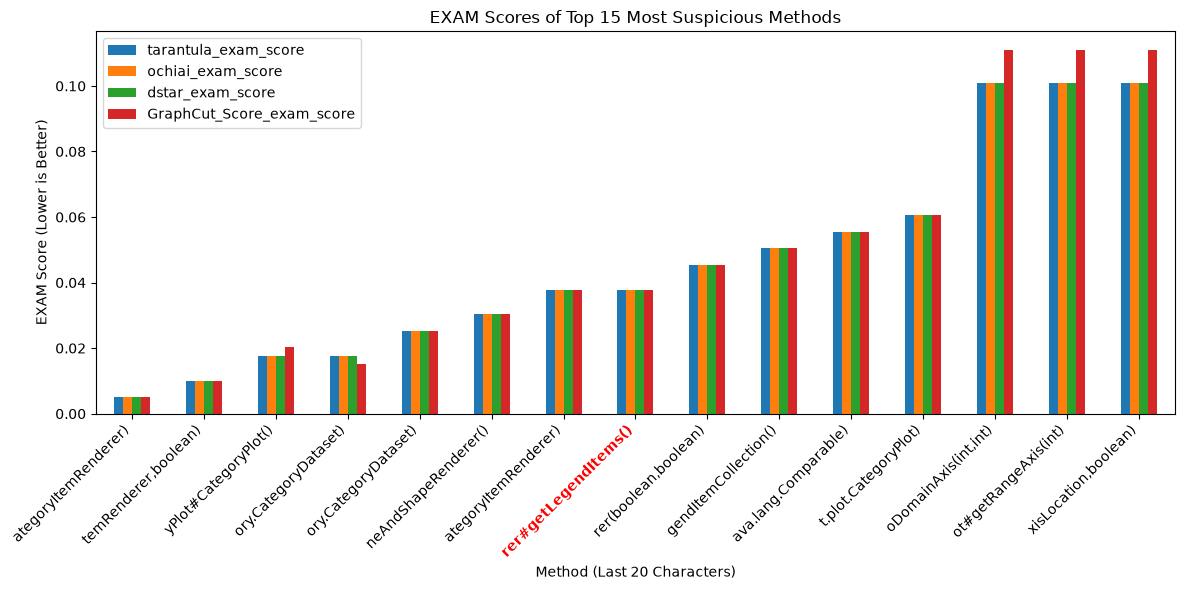

In [77]:
import matplotlib.pyplot as plt
k = 15
# 1. Setup the Top 10 dataframe exactly as before
top_k = merged_results.sort_values(by='tarantula_exam_score').head(k).copy()
top_k['Short_Method'] = top_k['Method'].str[-20:]
top_k.set_index('Short_Method', inplace=True)

exam_cols = ['tarantula_exam_score', 'ochiai_exam_score', 'dstar_exam_score', 'GraphCut_Score_exam_score']

# 2. Create the default plot and save it to 'ax'
ax = top_k[exam_cols].plot(kind='bar', figsize=(12, 6))

# 3. Add standard labels
plt.title(f'EXAM Scores of Top {k} Most Suspicious Methods')
plt.xlabel('Method (Last 20 Characters)')
plt.ylabel('EXAM Score (Lower is Better)')
plt.xticks(rotation=45, ha='right')

short_buggy_node = actual_buggy_node[-20:]

# Loop through the labels and turn the buggy one red and bold
for label in ax.get_xticklabels():
    if label.get_text() == short_buggy_node:
        label.set_color('red')
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

In [ ]:
def evaluate(project, bug_id, lambd=1.0):
    extraction_res = load_pregen_data(project, bug_id)

    G = json_to_digraph(extraction_res.graph_json)
    nodes = G.nodes()
    
    coverage_csv = instance / "coverage.csv"
    coverage_df = pd.read_csv(coverage_csv)
    print("Read Coverage csv")

    tarantula = compute_method_tarantula(coverage_csv)    
    ochiai = compute_method_ochiai(coverage_csv)
    dstar = compute_method_dstar(coverage_csv)

    print("Computed baselines")
    
    nodes_t = tarantula.keys()
    x = [node for node in nodes_t if node in nodes]
    assert len(nodes) == len(x)
    
    nodes_o = ochiai.keys()
    y = [node for node in nodes_o if node in nodes]
    assert len(nodes) == len(y)
    
    nodes_d = dstar.keys()
    z = [node for node in nodes_d if node in nodes]
    assert len(nodes) == len(z)
    
    sbfl_metrics = pd.DataFrame({
        "tarantula": {node: tarantula[node] for node in x if node in tarantula},
        "ochiai": {node: ochiai[node] for node in y if node in ochiai},
        "dstar": {node: dstar[node] for node in z if node in dstar},
    })
    
    sbfl_metrics = sbfl_metrics.reset_index().rename(columns={'index': 'Method'})
    
    cut_algo = BoykovJollyCut(G, tarantula, lambd=lambd)

    print("Applied cuts")
    
    cut_scores = []
    for node in cut_algo.nodes:
        e0, e1 = cut_algo.compute_min_marginals(node)
        confidence = e0 - e1 # Higher is more buggy
        cut_scores.append({"Method": node, "GraphCut_Score": confidence})
    
    cut_df = pd.DataFrame(cut_scores)
    merged_results = pd.merge(sbfl_metrics, cut_df, on="Method", how="left")

    metrics = ['tarantula', 'ochiai', 'dstar', 'GraphCut_Score']
    
    for metric in metrics:
        merged_results[f'{metric}_rank'] = merged_results[metric].rank(ascending=False, method='min')
    
    merged_results = merged_results.sort_values(by='tarantula_rank')
    total_methods = len(merged_results)
    
    metrics = ['tarantula', 'ochiai', 'dstar', 'GraphCut_Score']
    
    for metric in metrics:
        expected_rank = merged_results[metric].rank(ascending=False, method='average')
        merged_results[f'{metric}_expected_inspections'] = expected_rank
        merged_results[f'{metric}_exam_score'] = expected_rank / total_methods
    return merged_results


In [83]:
evaluate("Chart", 1, 1.0)

,Method,tarantula,ochiai,dstar,GraphCut_Score,tarantula_rank,ochiai_rank,dstar_rank,GraphCut_Score_rank,tarantula_expected_inspections,tarantula_exam_score,ochiai_expected_inspections,ochiai_exam_score,dstar_expected_inspections,dstar_exam_score,GraphCut_Score_expected_inspections,GraphCut_Score_exam_score
150,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.998180,0.447214,0.250000,6.307187e+00,1.0,1.0,1.0,1.0,1.0,0.005051,1.0,0.005051,1.0,0.005051,1.0,0.005051
151,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.996820,0.353553,0.142857,5.747571e+00,2.0,2.0,2.0,2.0,2.0,0.010101,2.0,0.010101,2.0,0.010101,2.0,0.010101
133,org.jfree.chart.plot.CategoryPlot#CategoryPlot(),0.993659,0.258199,0.071429,5.054424e+00,3.0,3.0,3.0,4.0,3.5,0.017677,3.5,0.017677,3.5,0.017677,4.0,0.020202
143,org.jfree.chart.plot.CategoryPlot#setDataset(o...,0.993659,0.258199,0.071429,5.054424e+00,3.0,3.0,3.0,3.0,3.5,0.017677,3.5,0.017677,3.5,0.017677,3.0,0.015152
144,org.jfree.chart.plot.CategoryPlot#setDataset(i...,0.990072,0.208514,0.045455,4.602439e+00,5.0,5.0,5.0,5.0,5.0,0.025253,5.0,0.025253,5.0,0.025253,5.0,0.025253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,org.jfree.chart.util.StandardGradientPaintTran...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,108.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,131.5,0.664141
77,org.jfree.chart.util.GradientPaintTransformTyp...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,156.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,158.0,0.797980
81,org.jfree.chart.event.RendererChangeEvent#Rend...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,188.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,193.0,0.974747
66,org.jfree.chart.text.TextAnchor#equals(java.la...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,108.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,131.5,0.664141


In [84]:
merged_results

,Method,tarantula,ochiai,dstar,GraphCut_Score,tarantula_rank,ochiai_rank,dstar_rank,GraphCut_Score_rank,tarantula_expected_inspections,tarantula_exam_score,ochiai_expected_inspections,ochiai_exam_score,dstar_expected_inspections,dstar_exam_score,GraphCut_Score_expected_inspections,GraphCut_Score_exam_score
150,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.998180,0.447214,0.250000,6.307187e+00,1.0,1.0,1.0,1.0,1.0,0.005051,1.0,0.005051,1.0,0.005051,1.0,0.005051
151,org.jfree.chart.plot.CategoryPlot#setRenderer(...,0.996820,0.353553,0.142857,5.747571e+00,2.0,2.0,2.0,2.0,2.0,0.010101,2.0,0.010101,2.0,0.010101,2.0,0.010101
133,org.jfree.chart.plot.CategoryPlot#CategoryPlot(),0.993659,0.258199,0.071429,5.054424e+00,3.0,3.0,3.0,4.0,3.5,0.017677,3.5,0.017677,3.5,0.017677,4.0,0.020202
143,org.jfree.chart.plot.CategoryPlot#setDataset(o...,0.993659,0.258199,0.071429,5.054424e+00,3.0,3.0,3.0,3.0,3.5,0.017677,3.5,0.017677,3.5,0.017677,3.0,0.015152
144,org.jfree.chart.plot.CategoryPlot#setDataset(i...,0.990072,0.208514,0.045455,4.602439e+00,5.0,5.0,5.0,5.0,5.0,0.025253,5.0,0.025253,5.0,0.025253,5.0,0.025253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,org.jfree.chart.util.StandardGradientPaintTran...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,108.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,131.5,0.664141
77,org.jfree.chart.util.GradientPaintTransformTyp...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,156.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,158.0,0.797980
81,org.jfree.chart.event.RendererChangeEvent#Rend...,0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,188.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,193.0,0.974747
106,"org.jfree.data.KeyedObjects2D#getObject(int,int)",0.000000,0.000000,0.000000,-1.000000e+09,91.0,91.0,91.0,108.0,144.5,0.729798,144.5,0.729798,144.5,0.729798,131.5,0.664141


In [88]:
# Full Benchmark
single_bug_instances

,total_nodes,total_edges,buggy_nodes,num_buggy_nodes,project,bug_id
Chart_1,198,239,[org.jfree.chart.renderer.category.AbstractCat...,1,Chart,1
Chart_11,7,6,[org.jfree.chart.util.ShapeUtilities#equal],1,Chart,11
Chart_12,184,239,[org.jfree.chart.plot.MultiplePiePlot#Multiple...,1,Chart,12
Chart_13,64,83,[org.jfree.chart.block.BorderArrangement#Range],1,Chart,13
Chart_17,110,157,[org.jfree.data.time.TimeSeries#delete],1,Chart,17
...,...,...,...,...,...,...
Time_22,650,1191,[org.joda.time.base.BasePeriod#BasePeriod],1,Time,22
Time_23,468,724,[org.joda.time.DateTimeZone#getConvertedId],1,Time,23
Time_24,780,1588,[org.joda.time.format.DateTimeParserBucket#com...,1,Time,24
Time_25,651,1234,[org.joda.time.DateTimeZone#getOffsetFromLocal],1,Time,25


In [92]:
import os
import pandas as pd
from tqdm import tqdm

# 1. Setup
output_dir = "eval_results"
os.makedirs(output_dir, exist_ok=True)
lambd_value = 1.0
failed_runs = []

# 2. Get a list of all unique projects (e.g., 'Chart', 'Time', 'Math')
projects = single_bug_instances['project'].unique()

print(f"Starting staged benchmark across {len(projects)} projects...\n")

# 3. The Outer Loop (By Project)
for project in projects:
    # Isolate just the bugs for this specific project
    project_df = single_bug_instances[single_bug_instances['project'] == project]
    print(f"Processing Project: {project} ({len(project_df)} bugs) ")
    
    # 4. The Inner Loop (By Bug ID)
    # This creates a fresh, clean progress bar for every project
    for index, row in tqdm(project_df.iterrows(), total=len(project_df), desc=f"{project} Progress"):
        bug_id = row['bug_id']
        filepath = os.path.join(output_dir, f"{project}_{bug_id}_{lambd_value}.csv")
        
        if os.path.exists(filepath):
            continue
            
        try:
            # Run the heavy evaluation
            result_df = evaluate(project, bug_id, lambd=lambd_value)
            
            # Save the results
            result_df.to_csv(filepath, index=False)
            
        except Exception as e:
            failed_runs.append({'project': project, 'bug_id': bug_id, 'error': str(e)})
            
    print("") # Adds a blank line between projects for readability

# 5. Final Summary
print(f"All Projects Complete")
if failed_runs:
    print(f"Encountered {len(failed_runs)} failed instances. Check the 'failed_runs' list for details.")

Starting staged benchmark across 17 projects...

Processing Project: Chart (17 bugs) 


Chart Progress: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [25:35<00:00, 90.32s/it]



Processing Project: Cli (4 bugs) 


Cli Progress: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [06:29<00:00, 97.44s/it]



Processing Project: Closure (2 bugs) 


...


Processing Project: Mockito (11 bugs) 


Mockito Progress: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [18:12<00:00, 99.31s/it]



Processing Project: Time (11 bugs) 


Time Progress: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [15:56<00:00, 86.94s/it]


All Projects Complete
Encountered 289 failed instances. Check the 'failed_runs' list for details.


In [93]:
failed_runs

[{'project': 'Chart', 'bug_id': 12, 'error': ''},
 {'project': 'Chart', 'bug_id': 17, 'error': ''},
 {'project': 'Chart', 'bug_id': 23, 'error': ''},
 {'project': 'Chart', 'bug_id': 25, 'error': ''},
 {'project': 'Chart', 'bug_id': 26, 'error': ''},
 {'project': 'Chart', 'bug_id': 4, 'error': ''},
 {'project': 'Chart', 'bug_id': 5, 'error': ''},
 {'project': 'Chart', 'bug_id': 7, 'error': ''},
 {'project': 'Chart', 'bug_id': 9, 'error': ''},
 {'project': 'Cli', 'bug_id': 35, 'error': ''},
 {'project': 'Cli', 'bug_id': 37, 'error': ''},
 {'project': 'Cli', 'bug_id': 38, 'error': ''},
 {'project': 'Cli', 'bug_id': 40, 'error': ''},
 {'project': 'Closure', 'bug_id': 1, 'error': ''},
 {'project': 'Closure', 'bug_id': 2, 'error': ''},
 {'project': 'Codec', 'bug_id': 10, 'error': ''},
 {'project': 'Codec', 'bug_id': 12, 'error': ''},
 {'project': 'Codec', 'bug_id': 15, 'error': ''},
 {'project': 'Codec', 'bug_id': 17, 'error': ''},
 {'project': 'Codec', 'bug_id': 18, 'error': ''},
 {'project

In [96]:
evaluate("Jsoup", 1, 1.0)

Read Coverage csv
Computed baselines


AssertionError: 

In [109]:
project = "Jsoup"
bug_id = 1
lambd=1.0
extraction_res = load_pregen_data(project, bug_id)

G = json_to_digraph(extraction_res.graph_json)
nodes = G.nodes()

data_dir = ROOT_DIR / "data" / "defects4j" / f"{project}_{bug_id}"
coverage_csv = data_dir / "coverage.csv"
coverage_df = pd.read_csv(coverage_csv)
print("Read Coverage csv")

tarantula = compute_method_tarantula(coverage_csv)    
ochiai = compute_method_ochiai(coverage_csv)
dstar = compute_method_dstar(coverage_csv)

print("Computed baselines")


Read Coverage csv
Computed baselines


In [110]:
nodes_t = tarantula.keys()
x = [node for node in nodes_t if node in nodes]
assert len(nodes) == len(x)

nodes_o = ochiai.keys()
y = [node for node in nodes_o if node in nodes]
assert len(nodes) == len(y)

nodes_d = dstar.keys()
z = [node for node in nodes_d if node in nodes]
assert len(nodes) == len(z)

sbfl_metrics = pd.DataFrame({
    "tarantula": {node: tarantula[node] for node in x if node in tarantula},
    "ochiai": {node: ochiai[node] for node in y if node in ochiai},
    "dstar": {node: dstar[node] for node in z if node in dstar},
})

sbfl_metrics = sbfl_metrics.reset_index().rename(columns={'index': 'Method'})

cut_algo = BoykovJollyCut(G, tarantula, lambd=1)

print("Applied cuts")

cut_scores = []
for node in cut_algo.nodes:
    e0, e1 = cut_algo.compute_min_marginals(node)
    confidence = e0 - e1 # Higher is more buggy
    cut_scores.append({"Method": node, "GraphCut_Score": confidence})

cut_df = pd.DataFrame(cut_scores)
merged_results = pd.merge(sbfl_metrics, cut_df, on="Method", how="left")

metrics = ['tarantula', 'ochiai', 'dstar', 'GraphCut_Score']

for metric in metrics:
    merged_results[f'{metric}_rank'] = merged_results[metric].rank(ascending=False, method='min')

merged_results = merged_results.sort_values(by='tarantula_rank')
total_methods = len(merged_results)

metrics = ['tarantula', 'ochiai', 'dstar', 'GraphCut_Score']

for metric in metrics:
    expected_rank = merged_results[metric].rank(ascending=False, method='average')
    merged_results[f'{metric}_expected_inspections'] = expected_rank
    merged_results[f'{metric}_exam_score'] = expected_rank / total_methods

merged_results

AssertionError: 

In [111]:
nodes_t = tarantula.keys()
x = [node for node in nodes_t if node in nodes]
len(nodes), len(x)

(163, 161)

In [108]:
G.nodes

NodeView(('org.jsoup.parser.TokenQueue#consumeToAny(java.lang.String[])', 'org.jsoup.parser.TokenQueue#consume()', 'org.jsoup.nodes.DataNode#outerHtml(java.lang.StringBuilder)', 'org.jsoup.nodes.DataNode#getWholeData()', 'org.jsoup.nodes.Element#html(java.lang.StringBuilder)', 'org.jsoup.nodes.TextNode#outerHtml(java.lang.StringBuilder)', 'org.jsoup.parser.Parser#parseStartTag()', 'org.jsoup.parser.Parser#addChildToParent(org.jsoup.nodes.Element,boolean)', 'org.jsoup.select.Collector#accumulateMatches(org.jsoup.nodes.Evaluator,java.util.List,org.jsoup.nodes.Element)', 'org.jsoup.nodes.Element#hashCode()', 'org.jsoup.nodes.Node#hashCode()', 'org.jsoup.nodes.Document#normalise(org.jsoup.nodes.Element)', 'org.jsoup.nodes.Node#removeChild(org.jsoup.nodes.Node)', 'org.jsoup.nodes.Element#appendChild(org.jsoup.nodes.Node)', 'org.jsoup.parser.Parser#popStackToClose(org.jsoup.parser.Tag)', 'org.jsoup.nodes.Element#tag()', 'org.jsoup.nodes.Element#children()', 'org.jsoup.parser.Tag#isData()', '

In [107]:
nodes_t

dict_keys(['org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#StandardURLTagFragmentGenerator()', 'org.jfree.chart.imagemap.StandardURLTagFragmentGenerator#generateURLFragment(java.lang.String)', 'org.jfree.chart.imagemap.ImageMapUtilities#ImageMapUtilities()', 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo)', 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,boolean)', 'org.jfree.chart.imagemap.ImageMapUtilities#writeImageMap(java.io.PrintWriter,java.lang.String,org.jfree.chart.ChartRenderingInfo,org.jfree.chart.imagemap.ToolTipTagFragmentGenerator,org.jfree.chart.imagemap.URLTagFragmentGenerator)', 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jfree.chart.ChartRenderingInfo)', 'org.jfree.chart.imagemap.ImageMapUtilities#getImageMap(java.lang.String,org.jfree.chart.ChartRenderingInfo,org

In [106]:
[node for node in nodes_t if node in nodes]

[]